<a href="https://colab.research.google.com/github/kenyi22/Tesis_MaestriaDataScience_UNI/blob/main/modelo_1402026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import cv2
import tensorflow as tf
from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import plotly.graph_objects as go

from google.colab import files #Librería para cargar ficheros directamente en Colab
%matplotlib inline

In [ ]:
# Usamos nuestros datos del google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#direccion de los archivos
sales_df = pd.read_csv("/content/drive/MyDrive/[UNI] Maestria de Data Science/4 ciclo/tesis/data/base_datos.csv", encoding="unicode_escape")

In [ ]:
#vemos la informacion de nuestros dataframe
sales_df.head(3)

,ï»¿fecha UTC,hora UTC,latitud (Âº),longitud (Âº),profundidad (km),magnitud (M)
0,1960-01-13,15:40:34.00,-16.145,-72.144,60,7.5
1,1960-01-15,09:30:24.00,-15.000,-75.000,70,7.0
2,1960-01-17,02:57:58.00,-14.500,-74.500,150,6.4


In [ ]:
sales_df.shape

(23519, 6)

In [ ]:
#renombramos los campos
sales_df=sales_df.rename(columns={
    'ï»¿fecha UTC': 'fecha_UTC',
    'hora UTC': 'hora_UTC',
    'latitud (Âº)': 'latitud',
    'longitud (Âº)': 'longitud',
    'profundidad (km)': 'profundidad',
    'magnitud (M)': 'magnitud'
})
display(sales_df.head(3))

,fecha_UTC,hora_UTC,latitud,longitud,profundidad,magnitud
0,1960-01-13,15:40:34.00,-16.145,-72.144,60,7.5
1,1960-01-15,09:30:24.00,-15.000,-75.000,70,7.0
2,1960-01-17,02:57:58.00,-14.500,-74.500,150,6.4


In [ ]:
# Veamos los tipos de datos
sales_df.dtypes

,0
fecha_UTC,object
hora_UTC,object
latitud,float64
longitud,float64
profundidad,int64
magnitud,float64


2. COMPRENSION DE LOS DATOS

Descripcion de los datos
  * Identificacion de atributos y volumenes

In [ ]:
# ==============================
# DETECCIÓN DE DUPLICADOS
# ==============================
# 1. Conteo de duplicados por fila completa
duplicados = sales_df[sales_df.duplicated(keep=False)]

print(f"[INFO] Se encontraron {duplicados.shape[0]} registros duplicados.")

[INFO] Se encontraron 0 registros duplicados.


In [ ]:
#para saber los tipos de variables
sales_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23519 entries, 0 to 23518
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fecha_UTC    23519 non-null  object 
 1   hora_UTC     23519 non-null  object 
 2   latitud      23519 non-null  float64
 3   longitud     23519 non-null  float64
 4   profundidad  23519 non-null  int64  
 5   magnitud     23519 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.1+ MB


In [ ]:
# Validamos el numero de registros nulos
sales_df.isnull().sum()

,0
fecha_UTC,0
hora_UTC,0
latitud,0
longitud,0
profundidad,0
magnitud,0


<Axes: >

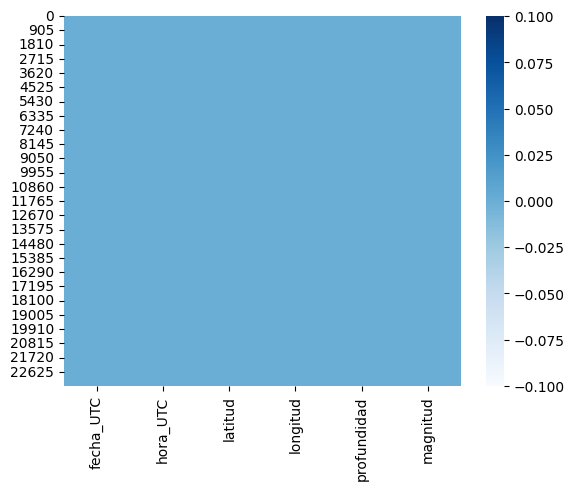

In [ ]:
# Realizamos un graficos de los registros nulos
sns.heatmap(sales_df.isnull() ,  cmap="Blues")

In [ ]:
# Obtenemos solo las variables numericas
num_cols = [i for i in sales_df.columns if ((sales_df[i].dtype == float) | (sales_df[i].dtype == np.int64))]
print(num_cols)

['latitud', 'longitud', 'profundidad', 'magnitud']


In [ ]:
#realizamos un analisis estadisticos de nuestros campos
sales_df[num_cols].describe().T.apply(lambda s: s.apply('{0:.2f}'.format))

,count,mean,std,min,25%,50%,75%,max
latitud,23519.00,-11.31,4.49,-23.40,-15.31,-11.54,-7.85,-1.49
longitud,23519.00,-75.75,3.08,-82.89,-77.80,-75.76,-73.73,-66.98
profundidad,23519.00,72.78,66.40,5.00,30.00,50.00,109.00,743.00
magnitud,23519.00,4.75,0.41,4.00,4.50,4.70,4.90,8.40


Exploracion de los datos
  * Identificacion de hipotesis, propiedades y objectos

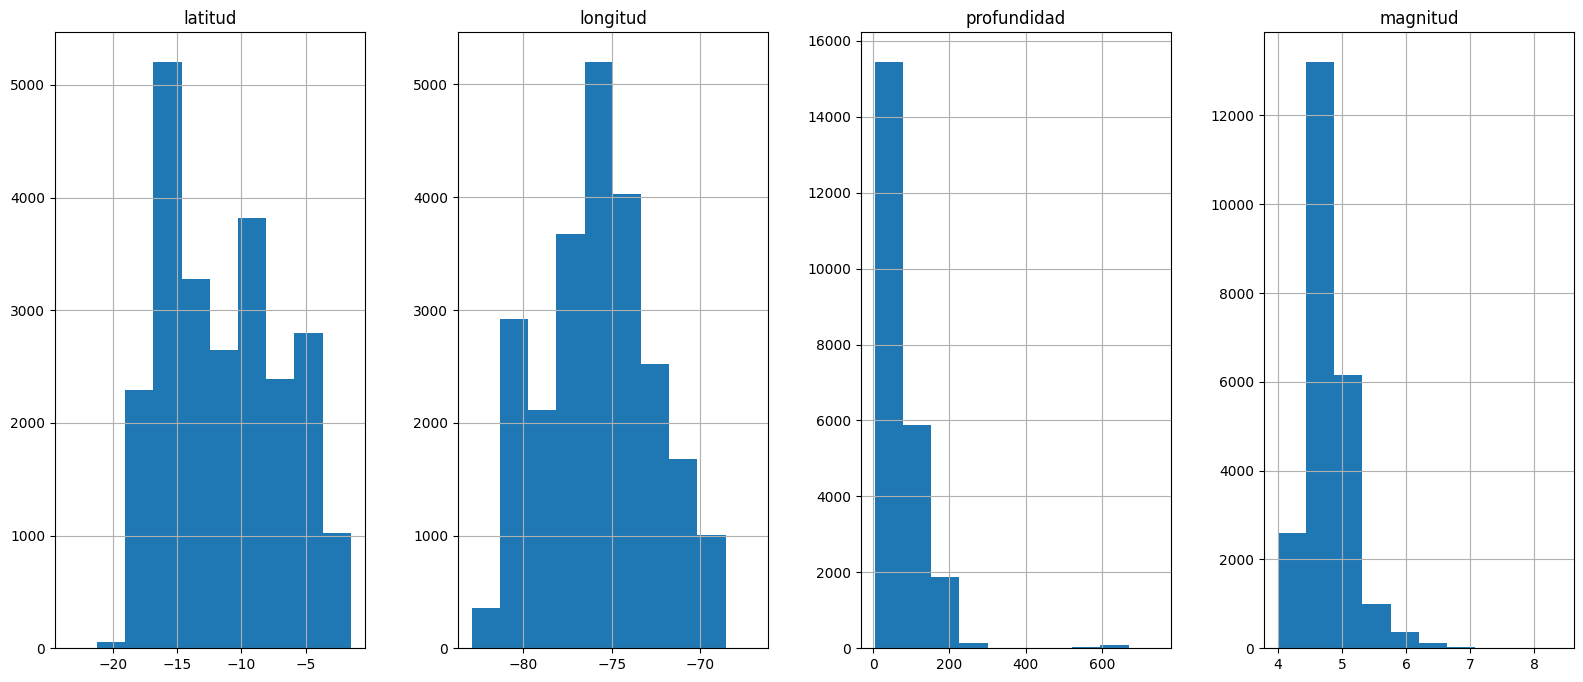

In [ ]:
#graficamos las variables numericas por medio del histograma
plt.rcParams['figure.figsize'] = [30, 8] ## ajustar la grafica
sales_df[num_cols].iloc[:, 0:6].hist(layout = (1,6)) ## genera un histograma a las variables numericas
plt.show()#visualizamos algunos graficos
plt.rcParams['figure.figsize'] = [10, 8]

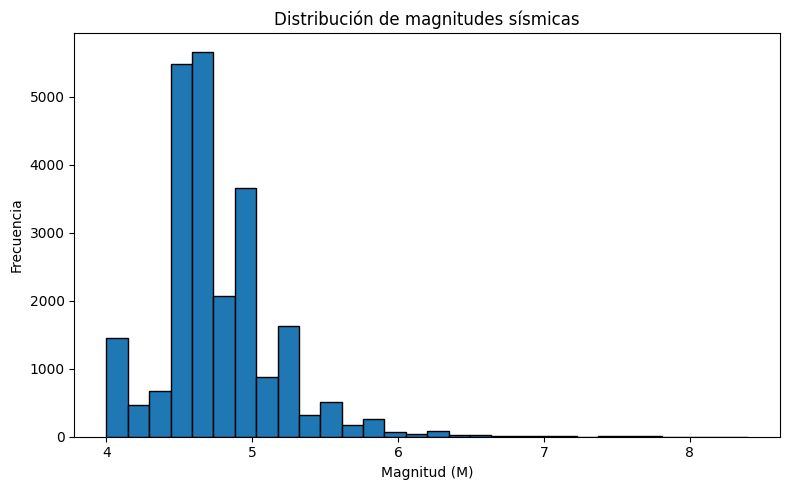

In [ ]:
# ---------- Gráfico 1: Histograma de magnitudes ----------
plt.figure(figsize=(8,5))
plt.hist(sales_df['magnitud'], bins=30, edgecolor="black")
plt.title("Distribución de magnitudes sísmicas")
plt.xlabel("Magnitud (M)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

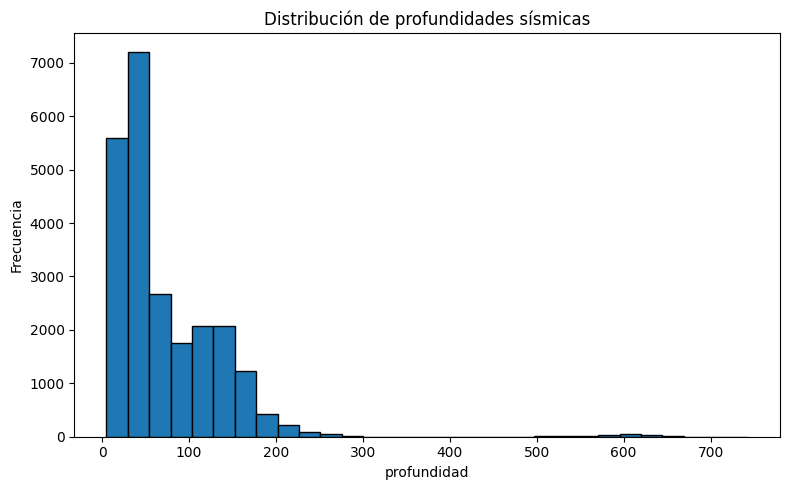

In [ ]:
# ---------- Gráfico 2: Histograma de Profundidad ----------
plt.figure(figsize=(8,5))
plt.hist(sales_df['profundidad'], bins=30, edgecolor="black")
plt.title("Distribución de profundidades sísmicas")
plt.xlabel("profundidad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

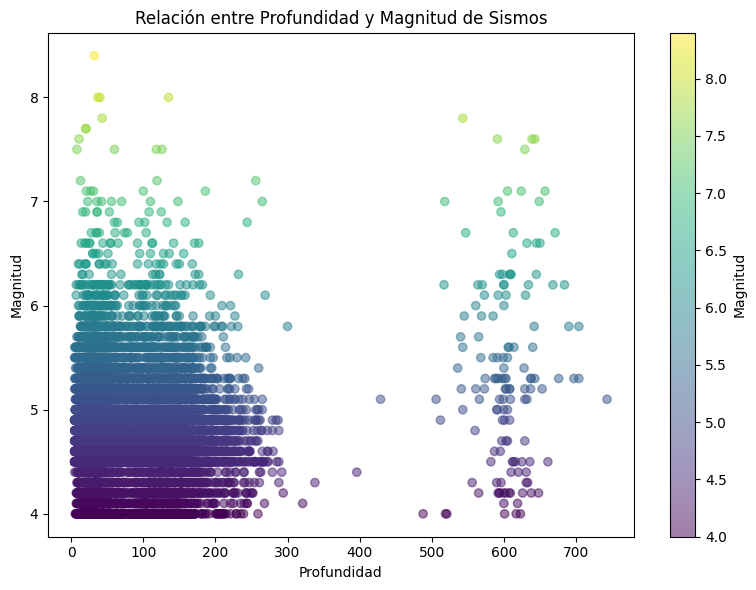

In [ ]:
# ---------- Relacion entre Profundidad y Magnitud de sismos ----------
plt.figure(figsize=(8,6))
sc = plt.scatter(sales_df["profundidad"], sales_df["magnitud"], alpha=0.5, c=sales_df["magnitud"], cmap="viridis")
plt.colorbar(sc, label="Magnitud")
plt.title("Relación entre Profundidad y Magnitud de Sismos")
plt.xlabel("Profundidad")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()

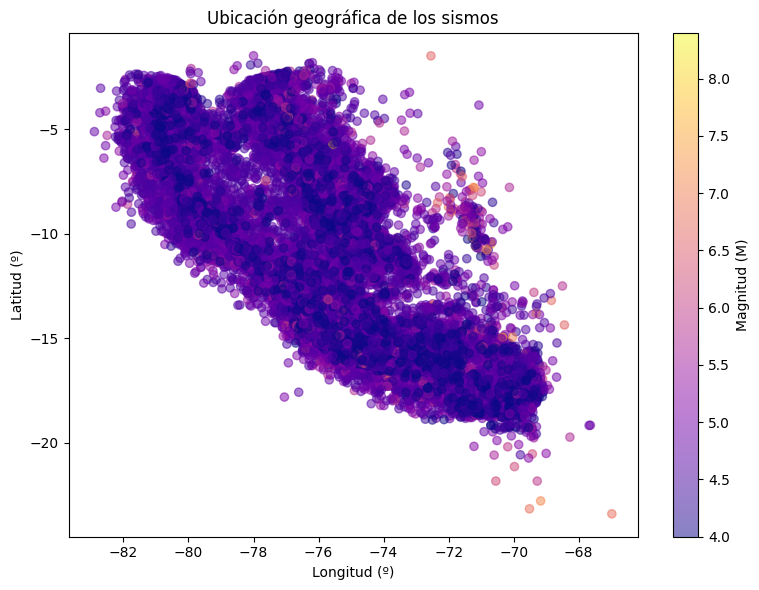

In [ ]:
# ---------- Relacion entre Latitud y Longitud ----------
plt.figure(figsize=(8,6))
c =sales_df["magnitud"] if "magnitud" in sales_df.columns else None
sc = plt.scatter(sales_df["longitud"], sales_df["latitud"], alpha=0.5, c=c, cmap="plasma" if c is not None else None)
if c is not None:
  plt.colorbar(sc, label="Magnitud (M)")
plt.title("Ubicación geográfica de los sismos")
plt.xlabel("Longitud (º)")
plt.ylabel("Latitud (º)")
plt.tight_layout()
plt.show()

In [ ]:
# ---------- Instalamos librerias para ver las relaciones de nuestros datos en el mapa de Peru ----------
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


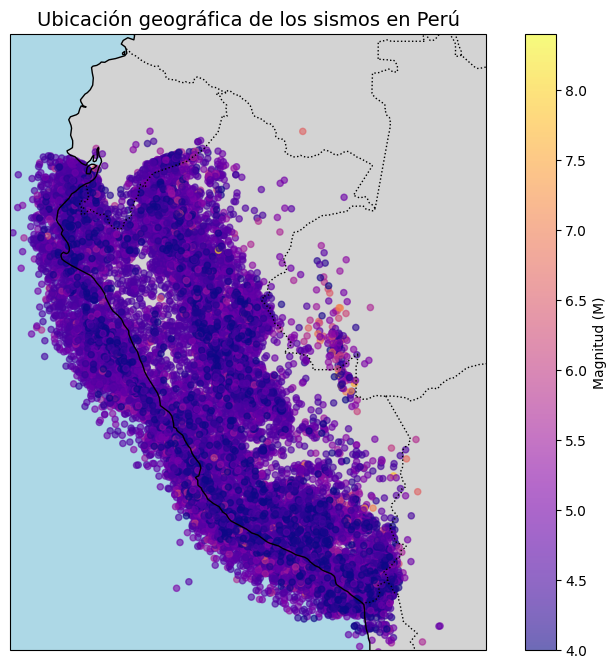

In [ ]:
# ---------- Grafica del Peru con todos los simos de nuestro dataframe ----------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Utilizaremos los datos de latitud, longitud y magnitud
lat = sales_df["latitud"]
lon = sales_df["longitud"]
mag = sales_df["magnitud"]

# Crear figura con proyección geográfica
plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Agregar costas, fronteras y relieve simple
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Usamos los datos sismicos definidos
sc = ax.scatter(lon, lat, c=mag, cmap="plasma", alpha=0.6, s=20, transform=ccrs.PlateCarree())
plt.colorbar(sc, ax=ax, label="Magnitud (M)")

# Enfocar en Perú (aprox. límites)
ax.set_extent([-83, -66, -20, 2], crs=ccrs.PlateCarree())

plt.title("Ubicación geográfica de los sismos en Perú", fontsize=14)
plt.show()

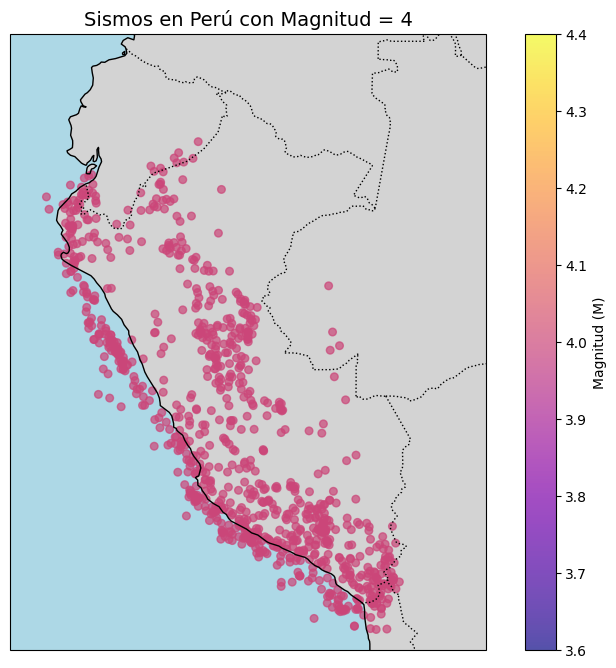

In [ ]:
# ---------- Grafica del Peru con los sismos de magnitud 4 ----------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Filtrar solo sismos con magnitud = 4
df_filtrado = sales_df[sales_df["magnitud"] == 4]

# Utilizaremos los datos de latitud, longitud y magnitud
lat = df_filtrado["latitud"]
lon = df_filtrado["longitud"]
mag = df_filtrado["magnitud"]

# Crear figura con proyección geográfica
plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Agregar costas, fronteras y relieve simple
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Usamos los datos sismicos definidos
sc = ax.scatter(lon, lat, c=mag, cmap="plasma", alpha=0.7, s=30, transform=ccrs.PlateCarree())
plt.colorbar(sc, ax=ax, label="Magnitud (M)")

# Enfocar en Perú (aprox.)
ax.set_extent([-83, -66, -20, 2], crs=ccrs.PlateCarree())

plt.title("Sismos en Perú con Magnitud = 4", fontsize=14)
plt.show()

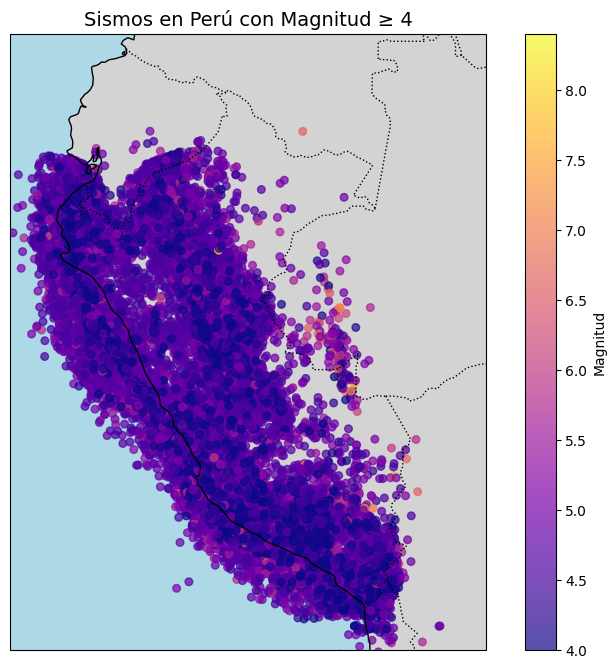

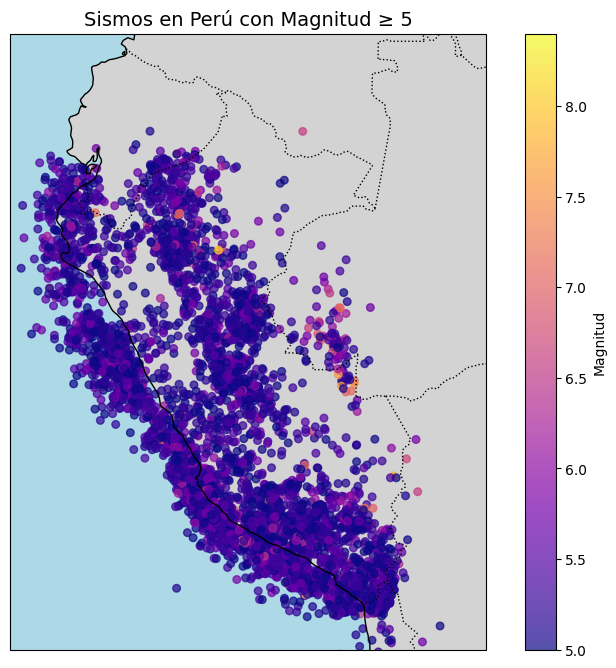

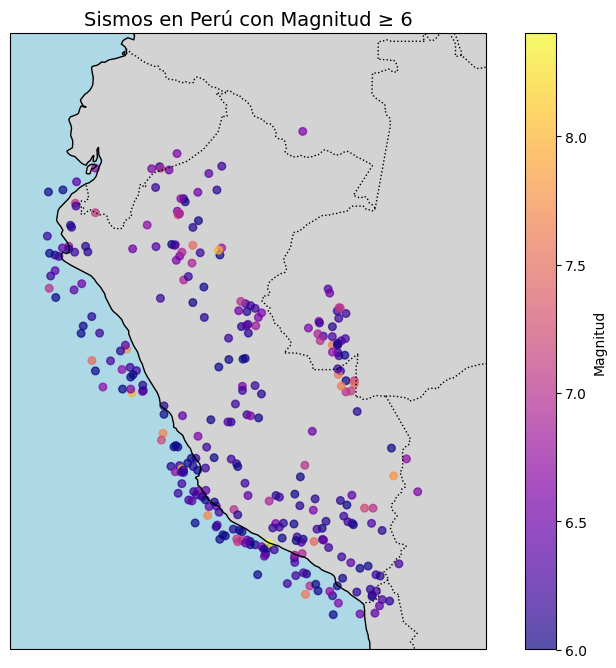

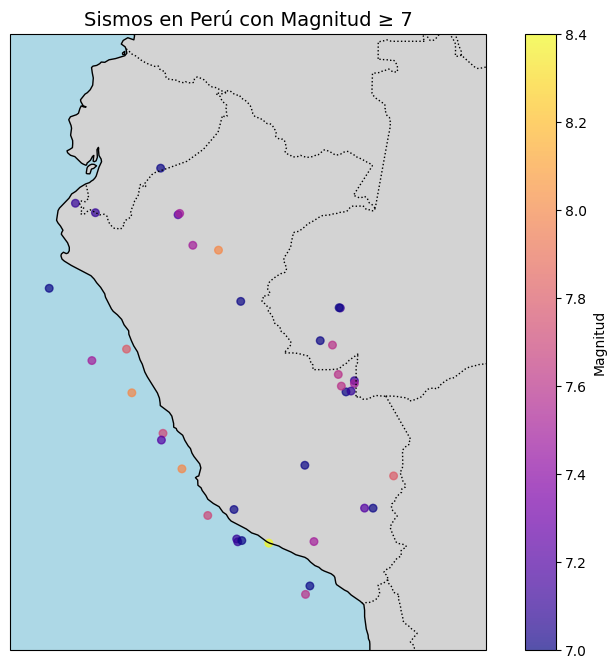

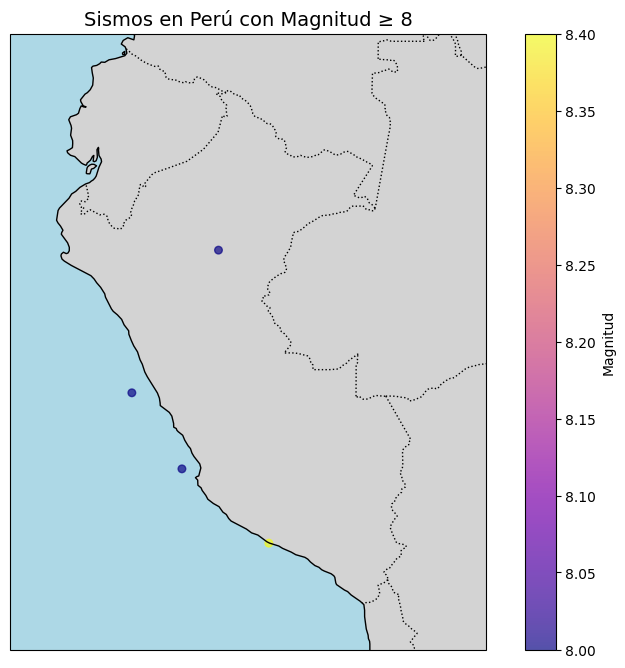

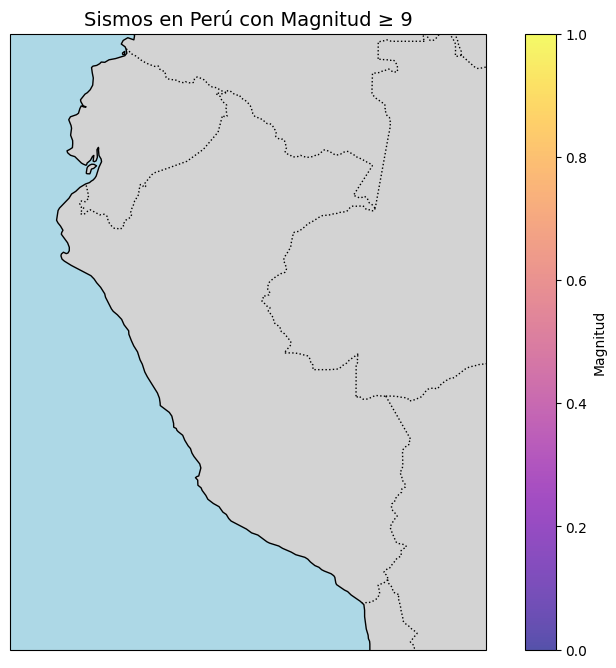

In [ ]:
# ---------- Grafica del Peru con los sismos de magnitud >=4 ----------
#se creo una funcion para reutilizar el codigo
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

#funcion de generacion de mapas
def generar_mapa(mag_min):
    df_filtrado = sales_df[sales_df["magnitud"] >= mag_min]

    plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Elementos base del mapa
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

    # Graficar sismos filtrados
    sc = ax.scatter(df_filtrado["longitud"], df_filtrado["latitud"],
                    c=df_filtrado["magnitud"], cmap="plasma", alpha=0.7, s=30,
                    transform=ccrs.PlateCarree())

    plt.colorbar(sc, ax=ax, label="Magnitud")

    # Ajustar vista sobre Perú
    ax.set_extent([-83, -66, -20, 2], crs=ccrs.PlateCarree())
    plt.title(f"Sismos en Perú con Magnitud ≥ {mag_min}", fontsize=14)
    plt.show()

# Utilizacion de la funcion de generacion de mapas
# se selecciono como base los sismos mayores o iguales a 4,5,6,7,8 y 9
for mag in [4,5, 6,7,8,9]:
    generar_mapa(mag)

In [ ]:
# Columnas derivadas
# se uso el campo de fecha_utc para crear los campos de año y decada
sales_df["año"] = pd.to_datetime(sales_df["fecha_UTC"]).dt.year
sales_df["decada"] = (sales_df["año"] // 10) * 10

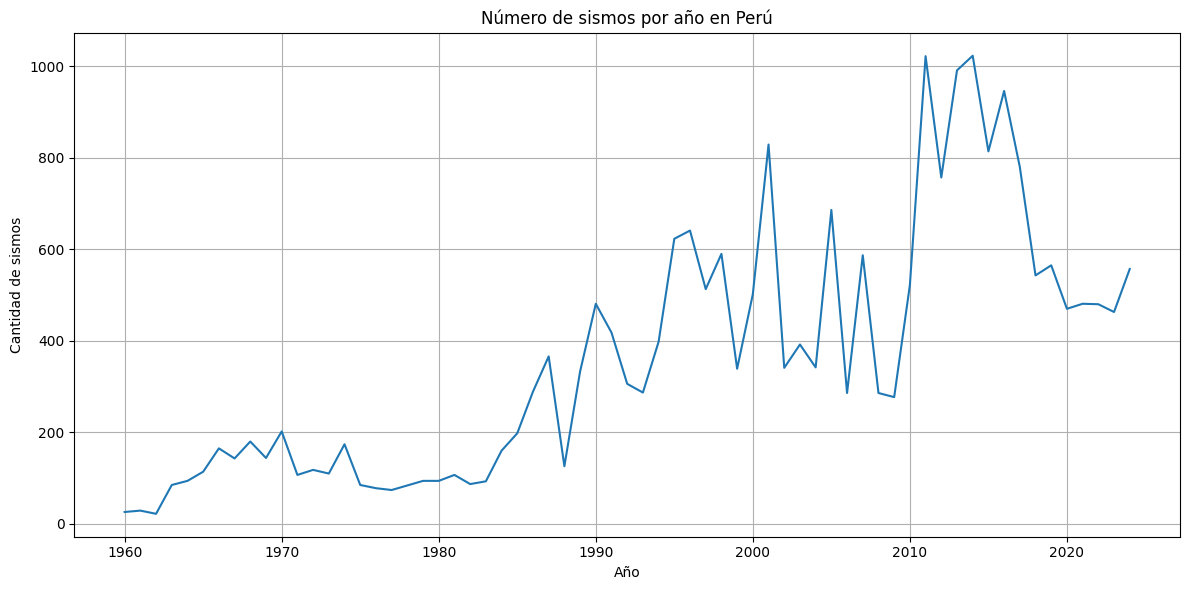

In [ ]:

# ------------- 1)Grafica de Numero de Sismos por Año -------------
sismos_por_año = sales_df.groupby("año").size()

plt.figure(figsize=(12, 6))
plt.plot(sismos_por_año.index, sismos_por_año.values)
plt.title("Número de sismos por año en Perú")
plt.xlabel("Año")
plt.ylabel("Cantidad de sismos")
plt.grid(True)
plt.tight_layout()
plt.show()

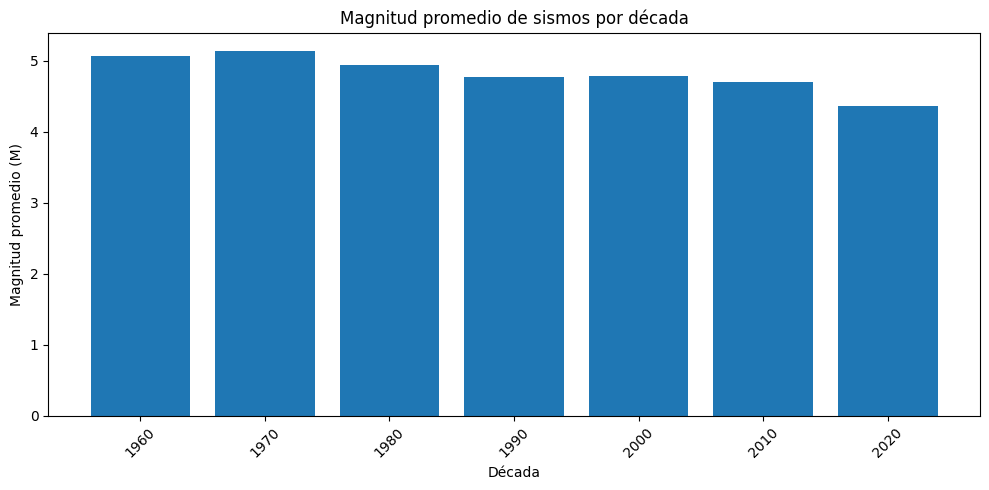

In [ ]:
# ------------- 2)Grafica de las Magnitudes promedio de los sismos en cada decada -------------
##agrupamos los datos segun la decada y magnitud del sismo para obtener los promedios
magnitud_decada = sales_df.groupby("decada")["magnitud"].mean()

plt.figure(figsize=(10, 5))
plt.bar(magnitud_decada.index.astype(str), magnitud_decada.values)
plt.title("Magnitud promedio de sismos por década")
plt.xlabel("Década")
plt.ylabel("Magnitud promedio (M)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Verificaciones y gestiones de calidad
  * Identificacion y soluciones de problemas

Outliers de variable numerica

In [ ]:
# Se calculan el porcentaje de outliers
Q1 = sales_df[num_cols].quantile(0.25) ## calcula el percentil 25% para las variables numéricas
Q3 = sales_df[num_cols].quantile(0.75) ## calcula el percentil 75% para las variables numéricas
IQR = Q3 - Q1  ## calcula el rango intercuartílico
## round para redondear
a = round(((sales_df[num_cols] < (Q1 - 1.5 * IQR)) | (sales_df[num_cols] > (Q3 + 1.5 * IQR))).sum()/sales_df.shape[0]*100,20)
a = pd.DataFrame(a).reset_index()
#a = a.reset_index()
a = a.sort_values(by = 0, ascending = False)
a

,index,0
3,magnitud,4.077554
2,profundidad,1.228794
1,longitud,0.004252
0,latitud,0.000000


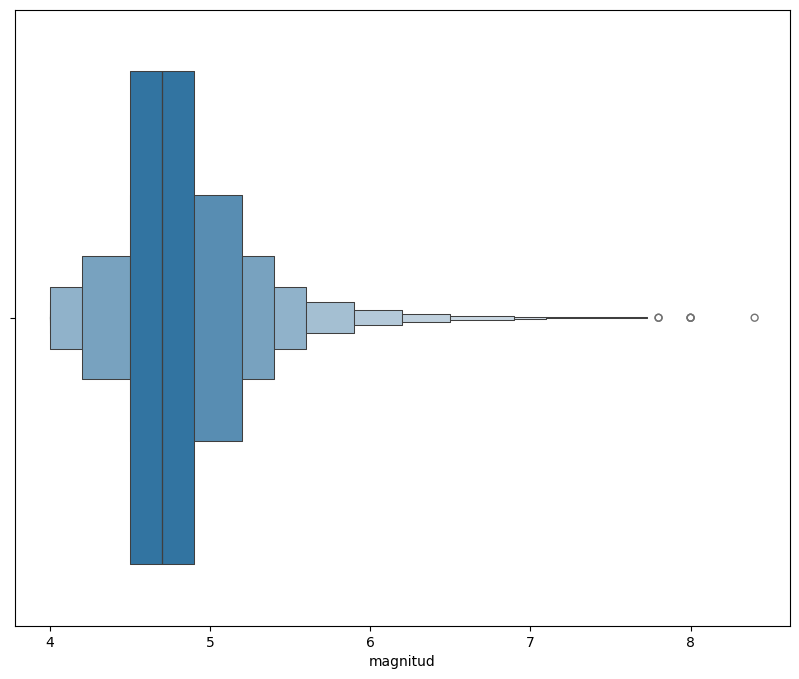

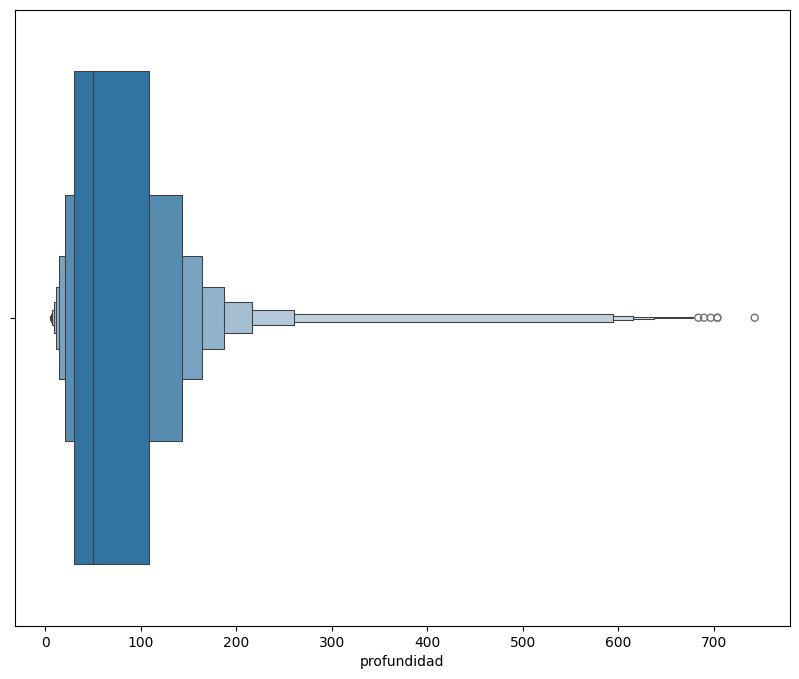

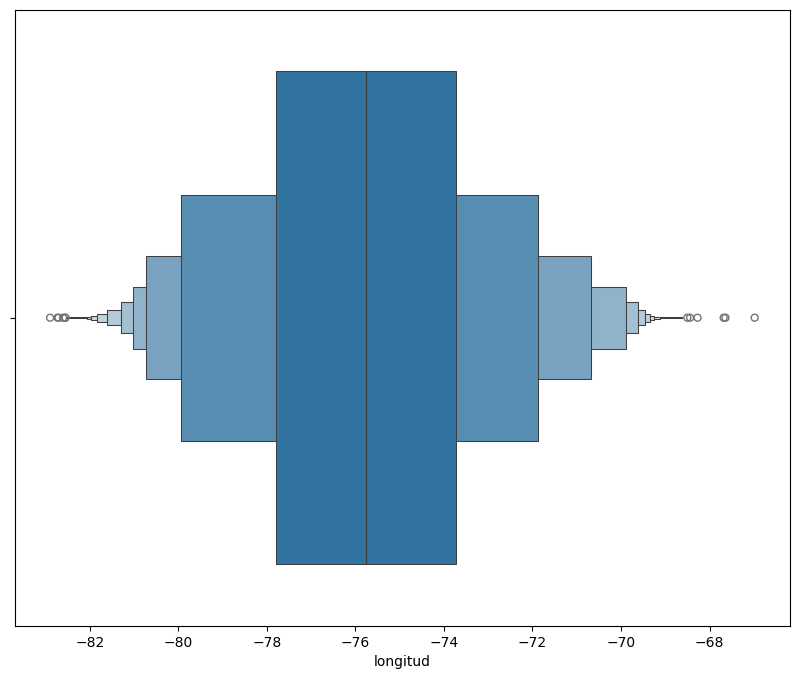

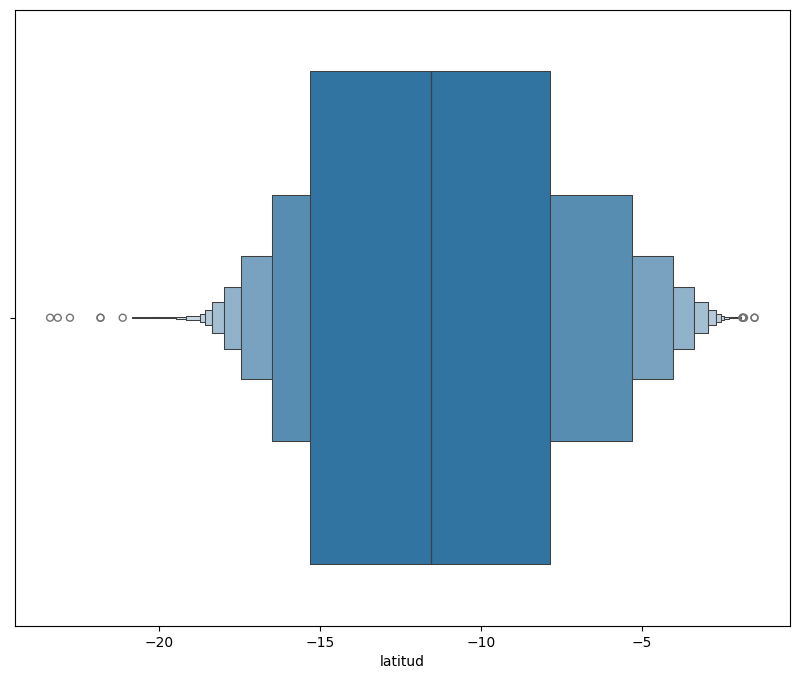

In [ ]:
#------------- Diagrama de cajas de las variables numericas-------------
# podemos visualizar datos en los extremos
for i in a['index'].unique():
    sns.boxenplot(x=sales_df[i])
    plt.show()

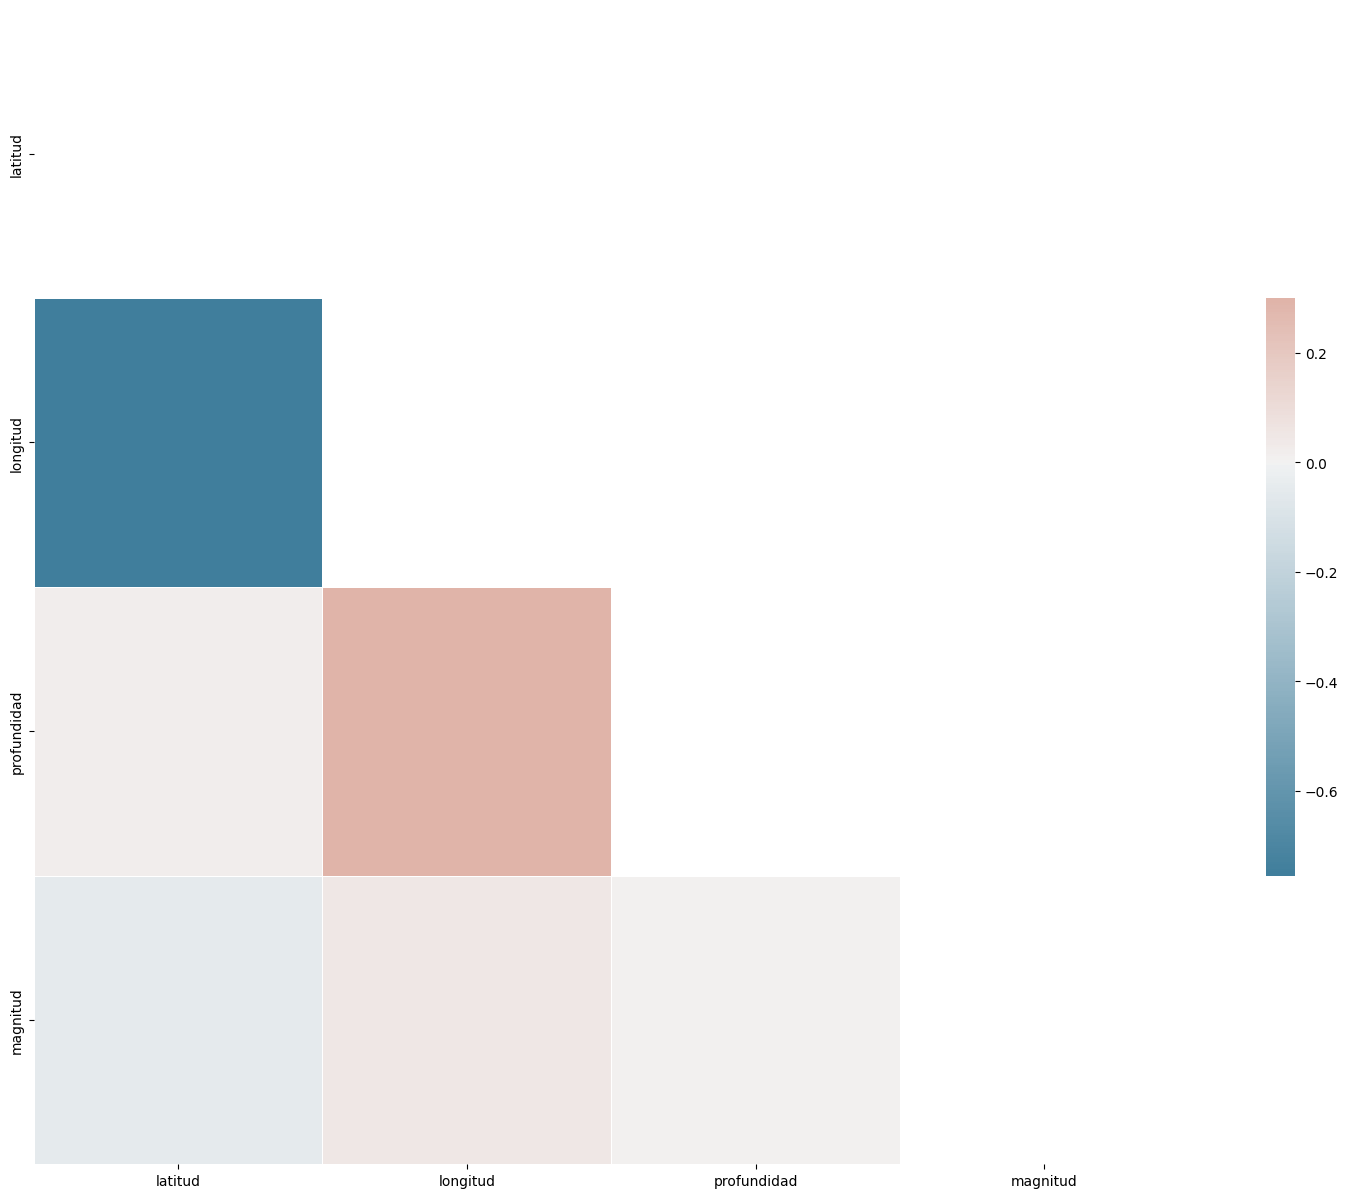

In [ ]:
# ------------- Diagrama de correlaciones -------------
Corr = sales_df[num_cols].corr(method = 'spearman')
# Generar una máscara para el triángulo superior
mask = np.triu(np.ones_like(Corr, dtype=bool))
# Configurar la figura matplotlib
f, ax = plt.subplots(figsize=(20, 15))
# Genere un mapa de colores divergente personalizado
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(Corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5});

3. PREPARACION DE LOS DATOS

Construccion del juego de datos
  * Ejecutar transformaciones previstas

In [ ]:
#damos formato al campo de hora utc a h:m:s
sales_df['hora_UTC'] = pd.to_datetime(sales_df['hora_UTC']).dt.strftime('%H:%M:%S')
display(sales_df.head(3))

/tmp/ipython-input-1307748008.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales_df['hora_UTC'] = pd.to_datetime(sales_df['hora_UTC']).dt.strftime('%H:%M:%S')


,fecha_UTC,hora_UTC,latitud,longitud,profundidad,magnitud,año,decada
0,1960-01-13,15:40:34,-16.145,-72.144,60,7.5,1960,1960
1,1960-01-15,09:30:24,-15.000,-75.000,70,7.0,1960,1960
2,1960-01-17,02:57:58,-14.500,-74.500,150,6.4,1960,1960


In [ ]:
# para crear un campo de fecha y hora en utc
sales_df['fecha_hora_UTC'] = pd.to_datetime(sales_df['fecha_UTC'] + ' ' + sales_df['hora_UTC'], errors='coerce')
# eliminamos los campos de fecha_utc y hora_utc
sales_df.drop(columns=['fecha_UTC', 'hora_UTC'], inplace=True)
# y creamos un campo timestamp, tomando de base el campo fecha_hora_utc
sales_df['timestamp'] = sales_df['fecha_hora_UTC'].astype("int64") / 1e9

# reordenar las columnas
cols = ['decada','año','fecha_hora_UTC','timestamp'] + [col for col in sales_df.columns if col not in ('decada','año','fecha_hora_UTC','timestamp')]
sales_df = sales_df[cols]

display(sales_df.head(3))

,decada,año,fecha_hora_UTC,timestamp,latitud,longitud,profundidad,magnitud
0,1960,1960,1960-01-13 15:40:34,-314525966.0,-16.145,-72.144,60,7.5
1,1960,1960,1960-01-15 09:30:24,-314375376.0,-15.000,-75.000,70,7.0
2,1960,1960,1960-01-17 02:57:58,-314226122.0,-14.500,-74.500,150,6.4


In [ ]:
#revisamos los tipos de variables
sales_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23519 entries, 0 to 23518
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   decada          23519 non-null  int32         
 1   año             23519 non-null  int32         
 2   fecha_hora_UTC  23519 non-null  datetime64[ns]
 3   timestamp       23519 non-null  float64       
 4   latitud         23519 non-null  float64       
 5   longitud        23519 non-null  float64       
 6   profundidad     23519 non-null  int64         
 7   magnitud        23519 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int32(2), int64(1)
memory usage: 1.3 MB


K-MEANS

In [ ]:
# llamamos a las librerias
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# definimos nuestros cluster
vars_cluster = ["latitud", "longitud", "profundidad", "magnitud"]

In [ ]:
X = sales_df[vars_cluster].copy()
idx_validos = X.index

In [ ]:
# ---------------- Normalización ----------------
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

In [ ]:
# ---------------- Método del codo --------------
k_min, k_max = 2, 10
ks = list(range(k_min, k_max + 1))
wcss = []

In [ ]:
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

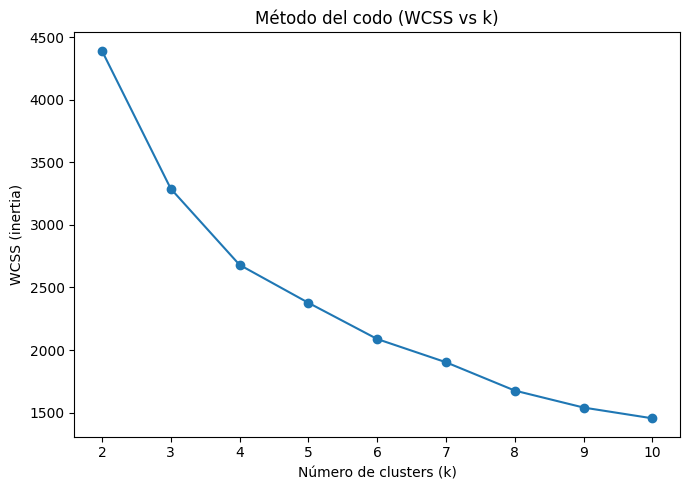

In [ ]:
# Graficar el codo
plt.figure(figsize=(7,5))
plt.plot(ks, wcss, marker="o")
plt.title("Método del codo (WCSS vs k)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS (inertia)")
plt.tight_layout()
plt.show()

In [ ]:
# ---- Heurística para elegir k (curvatura discreta) ----
diffs = np.diff(wcss)
second = np.diff(diffs)
if len(second) > 0:
    elbow_idx = int(np.argmax(np.abs(second)))
    k_optimo = ks[elbow_idx + 1]
else:
    k_optimo = ks[0]

print(f"[INFO] k óptimo estimado por codo: {k_optimo}")

[INFO] k óptimo estimado por codo: 3


In [ ]:
# ---------------- Aplicacion del Kmeans ---------
kmeans_final = KMeans(n_clusters=k_optimo, n_init=10, random_state=42)
labels = kmeans_final.fit_predict(X_scaled)

In [ ]:
# Reinyectar clusters al DataFrame original
sales_df.loc[idx_validos, "cluster"] = labels
sales_df["cluster"] = sales_df["cluster"].astype("Int64")

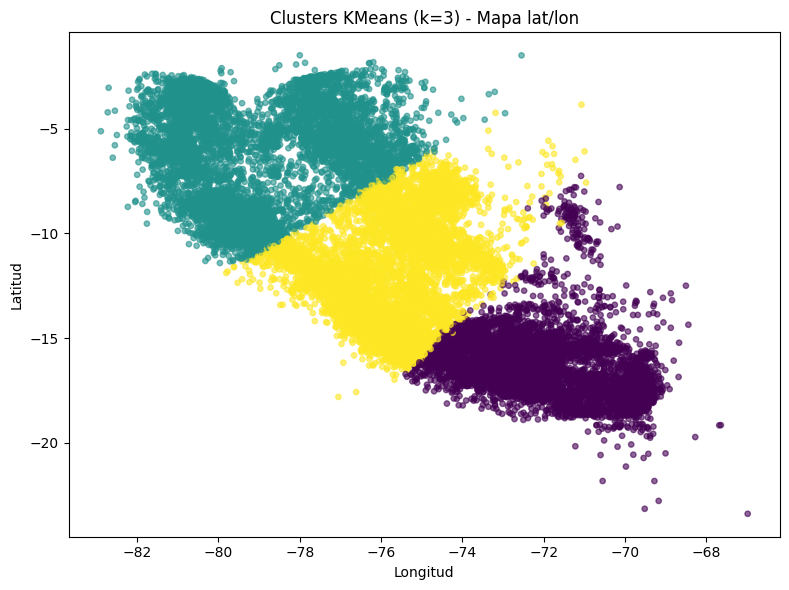

In [ ]:
# Realizamos un grafico para ver los cluster obtenidos y como se relaciona con las latitudes y longitudes
plt.figure(figsize=(8,6))
plt.scatter(sales_df.loc[idx_validos, "longitud"], sales_df.loc[idx_validos, "latitud"],
            c=labels, alpha=0.6, s=15)
plt.title(f"Clusters KMeans (k={k_optimo}) - Mapa lat/lon")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()

In [ ]:
# revisamos nuestros datos
sales_df.head(10)

,decada,año,fecha_hora_UTC,timestamp,latitud,longitud,profundidad,magnitud,cluster
0,1960,1960,1960-01-13 15:40:34,-314525966.0,-16.145,-72.144,60,7.5,0
1,1960,1960,1960-01-15 09:30:24,-314375376.0,-15.000,-75.000,70,7.0,2
2,1960,1960,1960-01-17 02:57:58,-314226122.0,-14.500,-74.500,150,6.4,2
3,1960,1960,1960-01-23 03:37:32,-313705348.0,-12.500,-68.500,300,5.8,0
4,1960,1960,1960-01-30 05:07:24,-313095156.0,-5.500,-77.500,100,5.7,1
5,1960,1960,1960-02-08 19:06:16,-312267224.0,-8.500,-74.500,136,5.3,2
6,1960,1960,1960-02-13 20:40:06,-311829594.0,-17.500,-70.000,150,5.9,0
7,1960,1960,1960-03-09 23:54:25,-309657935.0,-16.389,-73.817,80,6.2,0
8,1960,1960,1960-04-01 13:18:23,-307708897.0,-14.500,-73.500,100,6.1,0
9,1960,1960,1960-05-04 01:28:52,-304900268.0,-18.000,-71.500,100,5.0,0


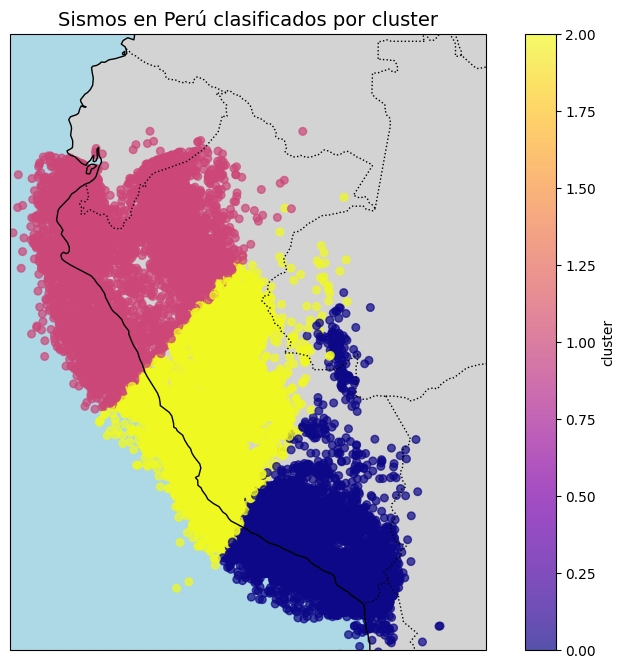

In [ ]:
# ---------------- Grafico de las magnitudes sismicas con datos de los cluster ---------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


df_filtrado = sales_df.copy()

lat = df_filtrado["latitud"]
lon = df_filtrado["longitud"]
clu = df_filtrado["cluster"]

# Crear figura con proyección geográfica
plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Agregar elementos del mapa
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Graficar
sc = ax.scatter(lon, lat, c=clu, cmap="plasma", alpha=0.7, s=30, transform=ccrs.PlateCarree())
plt.colorbar(sc, ax=ax, label="cluster")

# Enfocar en Perú (aprox.)
ax.set_extent([-83, -66, -20, 2], crs=ccrs.PlateCarree())

plt.title("Sismos en Perú clasificados por cluster", fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

MIN-MAX a la data base

In [ ]:
# aplicaremos metodos de normalizacion
# seleccionamos nuestros campo
vars_cluster = ["timestamp","latitud", "longitud", "profundidad", "magnitud","cluster"]

In [ ]:
sales_normalizado=sales_df[vars_cluster].copy()

In [ ]:
# visualizamos nuestros datos
sales_normalizado.head()

,timestamp,latitud,longitud,profundidad,magnitud,cluster
0,-314525966.0,-16.145,-72.144,60,7.5,0
1,-314375376.0,-15.000,-75.000,70,7.0,2
2,-314226122.0,-14.500,-74.500,150,6.4,2
3,-313705348.0,-12.500,-68.500,300,5.8,0
4,-313095156.0,-5.500,-77.500,100,5.7,1


In [ ]:
# Variables objetivo que se van a predecir y luego desnormalizar
target = ['magnitud', 'timestamp', 'cluster']

# Guardo los min y max originales del dataset (ANTES de normalizar)
min_vals = sales_normalizado[target].min().to_dict()
max_vals = sales_normalizado[target].max().to_dict()

In [ ]:
# ---------------- Normalización ----------------
# se uso el rando de -1 a 1, muy usado para algorimos de SNRNN y Transformer
scaler = MinMaxScaler(feature_range=(-1, 1))
sales_normalizado_minmax = scaler.fit_transform(sales_normalizado)

In [ ]:
sales_normalizado_minmax.shape

(23519, 6)

In [ ]:
# convertimos el arreglo de datos escalados (z = (x-u)/s) para ver los datos convertidos a la nueva escala
data_df = pd.DataFrame(sales_normalizado_minmax, columns=vars_cluster)
data_df.head(4)

,timestamp,latitud,longitud,profundidad,magnitud,cluster
0,-1.000000,-0.337922,0.351059,-0.850949,0.590909,-1.0
1,-0.999853,-0.233390,-0.007893,-0.823848,0.363636,1.0
2,-0.999707,-0.187743,0.054949,-0.607046,0.090909,1.0
3,-0.999199,-0.005154,0.809049,-0.200542,-0.181818,-1.0


MODELAMIENTO

RED NEURONAL RECURRENTE NORMALIZADA APILADA(SNRNN)

In [ ]:
# importamos librerias
import time
global_start = time.time()

In [ ]:
# creamos una copia para ser utilizada en los modelos
data_model_snrnn=data_df.copy()
data_model_snrnn.head(10)

,timestamp,latitud,longitud,profundidad,magnitud,cluster
0,-1.000000,-0.337922,0.351059,-0.850949,0.590909,-1.0
1,-0.999853,-0.233390,-0.007893,-0.823848,0.363636,1.0
2,-0.999707,-0.187743,0.054949,-0.607046,0.090909,1.0
3,-0.999199,-0.005154,0.809049,-0.200542,-0.181818,-1.0
4,-0.998604,0.633909,-0.322101,-0.742547,-0.227273,0.0
5,-0.997797,0.360025,0.054949,-0.644986,-0.409091,1.0
6,-0.997370,-0.461627,0.620524,-0.607046,-0.136364,-1.0
7,-0.995251,-0.360198,0.140791,-0.796748,0.000000,-1.0
8,-0.993350,-0.187743,0.180632,-0.742547,-0.045455,-1.0
9,-0.990610,-0.507274,0.431999,-0.742547,-0.545455,-1.0


In [ ]:
# importamos las librerias nesecarias
import pandas as pd
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, LayerNormalization
from sklearn.model_selection import train_test_split

In [ ]:
# variables de entrada
features = ['latitud', 'longitud', 'profundidad']
# lo que queremos predecir
# en las predicciones crearemos otras variables segun el rango temporal
# con lo cual el features se cambiara
target = ['magnitud', 'timestamp', 'cluster']

X = data_model_snrnn[features].values
y = data_model_snrnn[target].values



In [ ]:
# Redimensionar a (samples, timesteps, features)
# Se redimensiona porque los modelos de RNN, GRU y LSTM
# esperan la entrada de 3 dimensiones
# (batch_size, timesteps, features)
# X.shape[0], es para calcular las filas
# X.shape[1], es para calcular las columnas
# X_seq transforma la data a 3 dimensiones
X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# -------------------- División de datos --------------------
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.25, random_state=42)


In [ ]:
# -------------------- Definición del modelo SNRNN --------------------
inputs = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
# se aplicos los 3 modelos que conforman el SNRNN

#simple RNN
x = LayerNormalization()(inputs)
x = SimpleRNN(32, return_sequences=True)(x)
x = Dropout(0.5)(x)  # Dropout

#GRU
x = LayerNormalization()(x)
x = GRU(64, return_sequences=True)(x)
x = Dropout(0.4)(x)

#LSTM
x = LayerNormalization()(x)
x = LSTM(32)(x)
x = Dropout(0.4)(x)

# indicamos que variables va a predecir
outputs = Dense(3)(x)  # Predice: [magnitud, profundidad, timestamp]

# se genera el modelo
model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
# -------------------- Entrenamiento --------------------
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.25, verbose=1)

Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.2086 - mae: 0.3548 - val_loss: 0.0292 - val_mae: 0.1342
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0687 - mae: 0.2072 - val_loss: 0.0203 - val_mae: 0.1096
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0559 - mae: 0.1865 - val_loss: 0.0153 - val_mae: 0.0901
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0482 - mae: 0.1714 - val_loss: 0.0127 - val_mae: 0.0801
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0426 - mae: 0.1609 - val_loss: 0.0120 - val_mae: 0.0746
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0394 - mae: 0.1535 - val_loss: 0.0119 - val_mae: 0.0779
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0373 - mae: 0.1478 - val_loss: 0.0117 - val_mae: 0.0803
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0341 - mae: 0.1411 - val_loss: 0.0117 - val_mae: 0.0798
Epoch 9/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

In [ ]:
# Realizamos las prediciones con los datos de test
y_pred = model.predict(X_test)
print(y_pred[:5])

184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[[-0.7322002   0.65870005  0.8508056 ]
 [-0.7941061   0.78900766  0.00641991]
 [-0.6246282   0.08850363 -0.92791295]
 [-0.7410738   0.72301555  0.01046649]
 [-0.7830502   0.7851896   0.00859658]]


Desnormalizar

In [ ]:
# creamos una funcion para desnormalizar
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals[col_name]
    max_val = max_vals[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

In [ ]:
# dataframe de los valores test y pred
y_test_df = pd.DataFrame(y_test, columns=target)
y_pred_df = pd.DataFrame(y_pred, columns=target)

# Desnormalizar todas las columnas
for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

In [ ]:
y_test_df['cluster_real']=np.round(y_test_df['cluster_real'],2)
y_pred_df['cluster_pred']=np.round(y_pred_df['cluster_pred'],2)

In [ ]:
y_test_df[['magnitud_real','timestamp_real','cluster_real']].head()

,magnitud_real,timestamp_real,cluster_real
0,4.6,1.292527e+09,2.0
1,4.0,1.563669e+09,1.0
2,4.7,8.924561e+08,0.0
3,4.6,1.393940e+09,1.0
4,4.6,1.454184e+09,1.0


In [ ]:
y_pred_df[['magnitud_pred','timestamp_pred','cluster_pred']].head()

,magnitud_pred,timestamp_pred,cluster_pred
0,4.589159,1.385806e+09,1.85
1,4.452967,1.519384e+09,1.01
2,4.825818,8.012980e+08,0.07
3,4.569638,1.451736e+09,1.01
4,4.477290,1.515470e+09,1.01


In [ ]:
# obtencion de indicadores

from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
import numpy as np
import pandas as pd

# Inicializamos las listas para almacenar resultados
metricas = []
mae_list = []
mse_list = []
rmse_list = []
acc_list = []

# Evaluar cada variable: magnitud, timestamp, cluster
for col in ['magnitud', 'timestamp', 'cluster']:
    y_true = y_test_df[col + '_real']
    y_pred = y_pred_df[col + '_pred']

    # Calcular MAE, MSE, RMSE
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # Guardar
    metricas.append(col)
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)

    # Calcular accuracy SOLO para cluster
    if col == 'cluster':
        acc = accuracy_score(y_true.round().astype(int), y_pred.round().astype(int))
        acc_list.append(acc)
    else:
        acc_list.append(np.nan)  # No aplica para otras columnas

# Crear DataFrame resumen
resultado_snrnn = pd.DataFrame({
    'Variable': metricas,
    'MAE': mae_list,
    'MSE': mse_list,
    'RMSE': rmse_list,
    'Accuracy': acc_list
})


In [ ]:
# vemos los resultados
resultado_snrnn.head()

,Variable,MAE,MSE,RMSE,Accuracy
0,magnitud,1.737183e-01,5.882451e-02,2.425377e-01,NaN
1,timestamp,7.469553e+07,9.729164e+15,9.863653e+07,NaN
2,cluster,6.674489e-02,6.621734e-03,8.137404e-02,1.0


A 0.5 dias

In [ ]:
#usamos el dataframe normalizado
data_model_experimento=sales_normalizado.copy()
data_model_experimento.head(10)

,timestamp,latitud,longitud,profundidad,magnitud,cluster
0,-314525966.0,-16.145,-72.144,60,7.5,0
1,-314375376.0,-15.000,-75.000,70,7.0,2
2,-314226122.0,-14.500,-74.500,150,6.4,2
3,-313705348.0,-12.500,-68.500,300,5.8,0
4,-313095156.0,-5.500,-77.500,100,5.7,1
5,-312267224.0,-8.500,-74.500,136,5.3,2
6,-311829594.0,-17.500,-70.000,150,5.9,0
7,-309657935.0,-16.389,-73.817,80,6.2,0
8,-307708897.0,-14.500,-73.500,100,6.1,0
9,-304900268.0,-18.000,-71.500,100,5.0,0


In [ ]:
# unificacion de varios pasos
# importacion de librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, LayerNormalization, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
# -------------------- 1. Preprocesamiento --------------------
# reordenamos el dataframe por la variable timestamp
data_model_experimento = data_model_experimento.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_experimento['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 0.5
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)
print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_experimento['magnitud_t+0.5d'] = data_model_experimento['magnitud'].shift(-pasos)
data_model_experimento['timestamp_t+0.5d'] = data_model_experimento['timestamp'].shift(-pasos)
data_model_experimento['cluster_t+0.5d'] = data_model_experimento['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_experimento.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.25, random_state=42)

# -------------------- 5. Modelo SNRNN --------------------
# aplicamos el modelo
inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

x = LayerNormalization()(inputs_05)
x = SimpleRNN(32, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LayerNormalization()(x)
x = GRU(64, return_sequences=True)(x)
x = Dropout(0.4)(x)

x = LayerNormalization()(x)
x = LSTM(32)(x)
x = Dropout(0.4)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo con 20 epocas
model_05.fit(X_train_05, y_train_05, epochs=20, batch_size=64, validation_split=0.25, verbose=1)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_snrnn_05 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_snrnn_05 = resultado_snrnn_05.round(2)
print(resultado_snrnn_05)

Frecuencia promedio ≈ 87175.70 s → Shift de 0 filas
Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.2094 - mae: 0.3585 - val_loss: 0.0253 - val_mae: 0.1226
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0678 - mae: 0.2052 - val_loss: 0.0179 - val_mae: 0.0999
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0550 - mae: 0.1844 - val_loss: 0.0146 - val_mae: 0.0851
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0476 - mae: 0.1699 - val_loss: 0.0132 - val_mae: 0.0792
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0425 - mae: 0.1602 - val_loss: 0.0122 - val_mae: 0.0770
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0388 - mae: 0.1513 - val_loss: 0.0116 - val_mae: 0.0765
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0360 - mae: 0.1454 - val_loss: 0.0111 - val_mae: 0.0752
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0332 - mae: 0.1382 - val_loss: 0.0104 - val_mae: 0.0737
E

prediccion a 1 dia

In [ ]:
#importacion de librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, LayerNormalization, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
# -------------------- 1. Preprocesamiento --------------------
# reordenamos por la variable timestamp
data_model_experimento = data_model_experimento.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_experimento['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 1
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)
print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_experimento['magnitud_t+0.5d'] = data_model_experimento['magnitud'].shift(-pasos)
data_model_experimento['timestamp_t+0.5d'] = data_model_experimento['timestamp'].shift(-pasos)
data_model_experimento['cluster_t+0.5d'] = data_model_experimento['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_experimento.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.25, random_state=42)

# -------------------- 5. Modelo SNRNN --------------------
# aplicamos el modelo
inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

x = LayerNormalization()(inputs_05)
x = SimpleRNN(32, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LayerNormalization()(x)
x = GRU(64, return_sequences=True)(x)
x = Dropout(0.4)(x)

x = LayerNormalization()(x)
x = LSTM(32)(x)
x = Dropout(0.4)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo con 20 epocas
model_05.fit(X_train_05, y_train_05, epochs=20, batch_size=64, validation_split=0.25, verbose=1)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_snrnn_1 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_snrnn_1 = resultado_snrnn_1.round(2)
print(resultado_snrnn_1)

Frecuencia promedio ≈ 87175.70 s → Shift de 0 filas
Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.1898 - mae: 0.3382 - val_loss: 0.0235 - val_mae: 0.1195
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0672 - mae: 0.2043 - val_loss: 0.0160 - val_mae: 0.0919
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0535 - mae: 0.1820 - val_loss: 0.0135 - val_mae: 0.0821
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0473 - mae: 0.1699 - val_loss: 0.0129 - val_mae: 0.0827
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0421 - mae: 0.1581 - val_loss: 0.0134 - val_mae: 0.0860
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0379 - mae: 0.1499 - val_loss: 0.0126 - val_mae: 0.0832
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0349 - mae: 0.1428 - val_loss: 0.0123 - val_mae: 0.0844
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0339 - mae: 0.1404 - val_loss: 0.0111 - val_mae: 0.0774
E

Prediccion a 5 dias

In [ ]:
#importacion de librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, LayerNormalization, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

# -------------------- 1. Preprocesamiento --------------------
# reordenamos por la variable timestamp
data_model_experimento = data_model_experimento.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_experimento['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 5
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)

print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_experimento['magnitud_t+0.5d'] = data_model_experimento['magnitud'].shift(-pasos)
data_model_experimento['timestamp_t+0.5d'] = data_model_experimento['timestamp'].shift(-pasos)
data_model_experimento['cluster_t+0.5d'] = data_model_experimento['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_experimento.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.25, random_state=42)

# -------------------- 5. Modelo SNRNN --------------------
# aplicamos el modelo
inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

x = LayerNormalization()(inputs_05)
x = SimpleRNN(32, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LayerNormalization()(x)
x = GRU(64, return_sequences=True)(x)
x = Dropout(0.4)(x)

x = LayerNormalization()(x)
x = LSTM(32)(x)
x = Dropout(0.4)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo con 20 epocas
model_05.fit(X_train_05, y_train_05, epochs=20, batch_size=64, validation_split=0.25, verbose=1)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_snrnn_5 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_snrnn_5 = resultado_snrnn_5.round(2)
print(resultado_snrnn_5)

Frecuencia promedio ≈ 87175.70 s → Shift de 4 filas
Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.3503 - mae: 0.4581 - val_loss: 0.2384 - val_mae: 0.3208
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2625 - mae: 0.3620 - val_loss: 0.2358 - val_mae: 0.3151
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2522 - mae: 0.3461 - val_loss: 0.2343 - val_mae: 0.3110
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2522 - mae: 0.3426 - val_loss: 0.2336 - val_mae: 0.3079
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2475 - mae: 0.3354 - val_loss: 0.2332 - val_mae: 0.3079
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2427 - mae: 0.3296 - val_loss: 0.2334 - val_mae: 0.3061
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2432 - mae: 0.3282 - val_loss: 0.2329 - val_mae: 0.3067
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2403 - mae: 0.3241 - val_loss: 0.2328 - val_mae: 0.3046


Prediccion a 7 dias

In [ ]:
#importacion de librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, LayerNormalization, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

# -------------------- 1. Preprocesamiento --------------------
# reordenamos por la variable timestamp
data_model_experimento = data_model_experimento.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_experimento['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 7
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)

print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_experimento['magnitud_t+0.5d'] = data_model_experimento['magnitud'].shift(-pasos)
data_model_experimento['timestamp_t+0.5d'] = data_model_experimento['timestamp'].shift(-pasos)
data_model_experimento['cluster_t+0.5d'] = data_model_experimento['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_experimento.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.25, random_state=42)

# -------------------- 5. Modelo SNRNN --------------------
# aplicamos el modelo
inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

x = LayerNormalization()(inputs_05)
x = SimpleRNN(32, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LayerNormalization()(x)
x = GRU(64, return_sequences=True)(x)
x = Dropout(0.4)(x)

x = LayerNormalization()(x)
x = LSTM(32)(x)
x = Dropout(0.4)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo con 20 epocas
model_05.fit(X_train_05, y_train_05, epochs=20, batch_size=64, validation_split=0.25, verbose=1)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_snrnn_7 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_snrnn_7 = resultado_snrnn_7.round(2)
print(resultado_snrnn_7)

Frecuencia promedio ≈ 87175.70 s → Shift de 6 filas
Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.3359 - mae: 0.4456 - val_loss: 0.2391 - val_mae: 0.3195
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2610 - mae: 0.3602 - val_loss: 0.2363 - val_mae: 0.3139
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2519 - mae: 0.3452 - val_loss: 0.2351 - val_mae: 0.3094
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2493 - mae: 0.3389 - val_loss: 0.2356 - val_mae: 0.3096
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2474 - mae: 0.3357 - val_loss: 0.2339 - val_mae: 0.3060
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2478 - mae: 0.3318 - val_loss: 0.2336 - val_mae: 0.3043
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2450 - mae: 0.3288 - val_loss: 0.2336 - val_mae: 0.3058
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2385 - mae: 0.3210 - val_loss: 0.2331 - val_mae: 0.3029


In [ ]:
#medimos el tiempo de ejecucion
global_end = time.time()
print(f"Tiempo total de ejecución: {(global_end - global_start)/60:.2f} minutos")

Tiempo total de ejecución: 4.78 minutos


TRANSFORMER: UN MODELO DE APRENDIZAJE PROFUNDO BASADO EN LA TECNICA DE AUTOATENCION PARA PREDECIR MAGNITUDES DE TERREMOTOS

In [ ]:
import time
global_start = time.time()

In [ ]:
# -------------------- 1. base para el analisis con modelos transformer --------------------
# de nuestro dataframe normalizamos creamos una copia para nuestro analisis
data_model_transformer=data_df.copy()
data_model_transformer.head(10)

,timestamp,latitud,longitud,profundidad,magnitud,cluster
0,-1.000000,-0.337922,0.351059,-0.850949,0.590909,-1.0
1,-0.999853,-0.233390,-0.007893,-0.823848,0.363636,1.0
2,-0.999707,-0.187743,0.054949,-0.607046,0.090909,1.0
3,-0.999199,-0.005154,0.809049,-0.200542,-0.181818,-1.0
4,-0.998604,0.633909,-0.322101,-0.742547,-0.227273,0.0
5,-0.997797,0.360025,0.054949,-0.644986,-0.409091,1.0
6,-0.997370,-0.461627,0.620524,-0.607046,-0.136364,-1.0
7,-0.995251,-0.360198,0.140791,-0.796748,0.000000,-1.0
8,-0.993350,-0.187743,0.180632,-0.742547,-0.045455,-1.0
9,-0.990610,-0.507274,0.431999,-0.742547,-0.545455,-1.0


In [ ]:
# -------------------- 2. Separar variables --------------------
# separamos nuestras variables de features y target
# en esta ocasion algunos campos del feature y target se repiten
# pero al pronosticar con los rangos de tiempo, se cambiara al aplica las series temporales
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud', 'timestamp', 'cluster']

X = data_model_transformer[features].values
y = data_model_transformer[target].values

# Redimensionar a (samples, timesteps, features)
# Se redimensiona porque los modelos de RNN, GRU, LSTM y Transformer
# esperan la entrada de 3 dimensiones
# (batch_size, timesteps, features)
# X.shape[0], es para calcular las filas
# X.shape[1], es para calcular las columnas
# X_seq transforma la data a 3 dimensiones
X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

In [ ]:
# -------------------- 4. División --------------------
# dividimos nuestra data en train y test
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dense, Dropout, Input, GlobalAveragePooling1D, Add
from tensorflow.keras.models import Model

In [ ]:
# definimos una funcion con el encoder
def transformer_encoder(inputs, head_size=64, num_heads=8, ff_dim=512, dropout=0.02):
    # Normalización y atención
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])  # Residual

    # Feed-forward
    x2 = LayerNormalization(epsilon=1e-6)(x)
    x2 = Dense(ff_dim, activation="relu")(x2)
    x2 = Dropout(dropout)(x2)
    x2 = Dense(inputs.shape[-1])(x2)
    return Add()([x, x2])  # Residual

In [ ]:
# definimos nuestro input con el dataframe normalizado
inputs = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

# Agregar múltiples capas de encoder
x = inputs
for _ in range(6):  # 6 capas de codificacion (encoder layers)
    x = transformer_encoder(x, head_size=64, num_heads=8, ff_dim=512, dropout=0.02)

# Pooling y predicción
x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
# definimos los parametros de salida
outputs = Dense(3)(x)  # magnitud, timestamp, cluster
# aplicamos el modelo
model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
# -------------------- 6. Entrenamiento --------------------
# entrenamos el modelo con nuestro dataframe de train
model.fit(
    X_train, y_train,
    epochs=5,               #
    batch_size=32,          #
    validation_split=0.0,   # para monitorear overfitting
    verbose=1               # para ver progreso por epoch
)

# -------------------- 7. Predicción --------------------
# ahora realizamo una prediccion
y_pred = model.predict(X_test)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


588/588 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - loss: 0.1425 - mae: 0.2674
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0556 - mae: 0.1768
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.0387 - mae: 0.1446
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 0.0357 - mae: 0.1355
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.0321 - mae: 0.1271


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
# -------------------- 8. Desnormalización --------------------
# creamos una funcion de desnormalizacion
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals[col_name]
    max_val = max_vals[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val
# aplicamos a los dataframe
y_test_df = pd.DataFrame(y_test, columns=target)
y_pred_df = pd.DataFrame(y_pred, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

In [ ]:
# -------------------- 9. Evaluación --------------------
# creamos una funcion de evaluacion de metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# revisamos nuestros resultados
resultado_transform = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_transform = resultado_transform.round(2)
print(resultado_transform)

    Variable          MAE           MSE         RMSE  Accuracy
0   magnitud         0.11  2.000000e-02         0.16       NaN
1  timestamp  80895228.28  9.193743e+15  95884009.63       NaN
2    cluster         0.06  0.000000e+00         0.07       1.0


0.5 dias

In [ ]:
# -------------------- 1. base para el analisis con modelos transformer --------------------
# realizamos una copia de nuestro procesos previo a la normalizacion de min-max
data_model_transformer=sales_normalizado.copy()
data_model_transformer.head(10)

,timestamp,latitud,longitud,profundidad,magnitud,cluster
0,-314525966.0,-16.145,-72.144,60,7.5,0
1,-314375376.0,-15.000,-75.000,70,7.0,2
2,-314226122.0,-14.500,-74.500,150,6.4,2
3,-313705348.0,-12.500,-68.500,300,5.8,0
4,-313095156.0,-5.500,-77.500,100,5.7,1
5,-312267224.0,-8.500,-74.500,136,5.3,2
6,-311829594.0,-17.500,-70.000,150,5.9,0
7,-309657935.0,-16.389,-73.817,80,6.2,0
8,-307708897.0,-14.500,-73.500,100,6.1,0
9,-304900268.0,-18.000,-71.500,100,5.0,0


In [ ]:
# -------------------- 1. Preprocesamiento --------------------
# reordenamos por medio de la variable de timestamp
data_model_transformer = data_model_transformer.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_transformer['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 0.5
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)
print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_transformer['magnitud_t+0.5d'] = data_model_transformer['magnitud'].shift(-pasos)
data_model_transformer['timestamp_t+0.5d'] = data_model_transformer['timestamp'].shift(-pasos)
data_model_transformer['cluster_t+0.5d'] = data_model_transformer['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_transformer.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# -------------------- 5. Modelo TRANSFORMER --------------------
# aplicamos el modelo
def transformer_encoder(inputs, head_size=64, num_heads=8, ff_dim=512, dropout=0.02):
    # Normalización y atención
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])  # Residual

    # Feed-forward
    x2 = LayerNormalization(epsilon=1e-6)(x)
    x2 = Dense(ff_dim, activation="relu")(x2)
    x2 = Dropout(dropout)(x2)
    x2 = Dense(inputs.shape[-1])(x2)
    return Add()([x, x2])  # Residual

inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

# Agregar múltiples capas de encoder
x = inputs_05
for _ in range(6):  # 6 encoder layers
    x = transformer_encoder(x, head_size=64, num_heads=8, ff_dim=512, dropout=0.02)

# Pooling y predicción
x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)  # magnitud, timestamp, cluster

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo a 5 epocas
model_05.fit(
    X_train_05, y_train_05,
    epochs=5,              #
    batch_size=32,          #
    validation_split=0.0,   # para monitorear overfitting
    verbose=1               # para ver progreso por epoch
)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_transform_05 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_transform_05 = resultado_transform_05.round(2)
print(resultado_transform_05)

Frecuencia promedio ≈ 87175.70 s → Shift de 0 filas
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


588/588 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - loss: 0.1777 - mae: 0.2995
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.0557 - mae: 0.1732
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.0386 - mae: 0.1425
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.0346 - mae: 0.1344
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 0.0330 - mae: 0.1302


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
    Variable          MAE           MSE         RMSE  Accuracy
0   magnitud         0.17  5.000000e-02         0.22       NaN
1  timestamp  80501761.56  9.852936e+15  99261957.87       NaN
2    cluster         0.09  1.000000e-02         0.10       1.0


1 dia

In [ ]:
# -------------------- 1. Preprocesamiento --------------------
# reordenamos por la variable timestamp
data_model_transformer = data_model_transformer.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_transformer['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 1
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)

print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_transformer['magnitud_t+0.5d'] = data_model_transformer['magnitud'].shift(-pasos)
data_model_transformer['timestamp_t+0.5d'] = data_model_transformer['timestamp'].shift(-pasos)
data_model_transformer['cluster_t+0.5d'] = data_model_transformer['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_transformer.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# -------------------- 5. Modelo TRANSFORMER --------------------
# aplicamos el modelo
def transformer_encoder(inputs, head_size=64, num_heads=8, ff_dim=512, dropout=0.02):
    # Normalización y atención
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])  # Residual

    # Feed-forward
    x2 = LayerNormalization(epsilon=1e-6)(x)
    x2 = Dense(ff_dim, activation="relu")(x2)
    x2 = Dropout(dropout)(x2)
    x2 = Dense(inputs.shape[-1])(x2)
    return Add()([x, x2])  # Residual

inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

# Agregar múltiples capas de encoder
x = inputs_05
for _ in range(6):  # 6 encoder layers
    x = transformer_encoder(x, head_size=64, num_heads=8, ff_dim=512, dropout=0.02)

# Pooling y predicción
x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)  # magnitud, timestamp, cluster

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo con 5 epocas
model_05.fit(
    X_train_05, y_train_05,
    epochs=5,              #
    batch_size=32,          #
    validation_split=0.0,   # para monitorear overfitting
    verbose=1               # para ver progreso por epoch
)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_transform_1 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_transform_1 = resultado_transform_1.round(2)
print(resultado_transform_1)

Frecuencia promedio ≈ 87175.70 s → Shift de 0 filas
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


588/588 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - loss: 0.1263 - mae: 0.2557
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.0490 - mae: 0.1665
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.0357 - mae: 0.1368
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 0.0322 - mae: 0.1282
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 0.0310 - mae: 0.1240


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
    Variable          MAE           MSE         RMSE  Accuracy
0   magnitud         0.13  3.000000e-02         0.18       NaN
1  timestamp  50081931.57  3.866300e+15  62179576.99       NaN
2    cluster         0.05  0.000000e+00         0.06       1.0


5 dias

In [ ]:
# -------------------- 1. Preprocesamiento --------------------
# reordenamos por la variable timestamp
data_model_transformer = data_model_transformer.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_transformer['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 5
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)

print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_transformer['magnitud_t+0.5d'] = data_model_transformer['magnitud'].shift(-pasos)
data_model_transformer['timestamp_t+0.5d'] = data_model_transformer['timestamp'].shift(-pasos)
data_model_transformer['cluster_t+0.5d'] = data_model_transformer['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_transformer.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# -------------------- 5. Modelo TRANSFORMER --------------------
# aplicamos el modelo
def transformer_encoder(inputs, head_size=64, num_heads=8, ff_dim=512, dropout=0.02):
    # Normalización y atención
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])  # Residual

    # Feed-forward
    x2 = LayerNormalization(epsilon=1e-6)(x)
    x2 = Dense(ff_dim, activation="relu")(x2)
    x2 = Dropout(dropout)(x2)
    x2 = Dense(inputs.shape[-1])(x2)
    return Add()([x, x2])  # Residual

inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

# Agregar múltiples capas de encoder
x = inputs_05
for _ in range(6):  # 6 encoder layers
    x = transformer_encoder(x, head_size=64, num_heads=8, ff_dim=512, dropout=0.02)

# Pooling y predicción
x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)  # magnitud, timestamp, cluster

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo con 5 epocas
model_05.fit(
    X_train_05, y_train_05,
    epochs=5,              #
    batch_size=32,          #
    validation_split=0.0,   # para monitorear overfitting
    verbose=1               # para ver progreso por epoch
)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_transform_5 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_transform_5 = resultado_transform_5.round(2)
print(resultado_transform_5)

Frecuencia promedio ≈ 87175.70 s → Shift de 4 filas
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


588/588 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - loss: 0.4144 - mae: 0.4576
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.2639 - mae: 0.3470
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.2444 - mae: 0.3256
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.2371 - mae: 0.3133
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.2393 - mae: 0.3129


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
    Variable          MAE           MSE          RMSE  Accuracy
0   magnitud         0.27  1.500000e-01  3.800000e-01       NaN
1  timestamp  83214846.45  1.029034e+16  1.014413e+08       NaN
2    cluster         0.71  6.600000e-01  8.200000e-01      0.32


7 dias

In [ ]:
# -------------------- 1. Preprocesamiento --------------------
# reordenamos por la variable timestamp
data_model_transformer = data_model_transformer.sort_values('timestamp').reset_index(drop=True)

# obtenemos la frecuencia, definimos el horizonte y calculamos los pasos
frecuencia_seg = data_model_transformer['timestamp'].diff().mean()  # promedio de segundos entre eventos
# definimos el horizonte de analisis
horizonte_dias = 7
# calculamos los pasos
# multiplicamos 86400 para transformar dia a segundos
pasos = int((horizonte_dias * 86400) / frecuencia_seg)

print(f"Frecuencia promedio ≈ {frecuencia_seg:.2f} s → Shift de {pasos} filas")

# Aplicar shift, porque veremos series de tiempo
# debemos preparar nuestra data con el horizonte definido
data_model_transformer['magnitud_t+0.5d'] = data_model_transformer['magnitud'].shift(-pasos)
data_model_transformer['timestamp_t+0.5d'] = data_model_transformer['timestamp'].shift(-pasos)
data_model_transformer['cluster_t+0.5d'] = data_model_transformer['cluster'].shift(-pasos)

# Eliminar filas con NaNs (por el shift)
df_modelo_05 = data_model_transformer.dropna(subset=['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d'])

# -------------------- 2. Separar variables --------------------
# separamos variables de features y target
features = ['timestamp', 'latitud', 'longitud', 'profundidad', 'magnitud', 'cluster']
target = ['magnitud_t+0.5d', 'timestamp_t+0.5d', 'cluster_t+0.5d']

X_raw = df_modelo_05[features].values
y_raw = df_modelo_05[target].values

# -------------------- 3. Normalización --------------------
# aplicamos normalizacion de MinMax
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw)

X_seq = X.reshape((X.shape[0], 1, X.shape[1]))

# Guardar min-max para desnormalizar
min_vals_y = df_modelo_05[target].min().to_dict()
max_vals_y = df_modelo_05[target].max().to_dict()

# -------------------- 4. División --------------------
# dividimos nuestra data para test y train
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# -------------------- 5. Modelo TRANSFORMER --------------------
# aplicamos el modelo
def transformer_encoder(inputs, head_size=64, num_heads=8, ff_dim=512, dropout=0.02):
    # Normalización y atención
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])  # Residual

    # Feed-forward
    x2 = LayerNormalization(epsilon=1e-6)(x)
    x2 = Dense(ff_dim, activation="relu")(x2)
    x2 = Dropout(dropout)(x2)
    x2 = Dense(inputs.shape[-1])(x2)
    return Add()([x, x2])  # Residual

inputs_05 = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

# Agregar múltiples capas de encoder
x = inputs_05
for _ in range(6):  # 6 encoder layers
    x = transformer_encoder(x, head_size=64, num_heads=8, ff_dim=512, dropout=0.02)

# Pooling y predicción
x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
# definimos nuestros output
outputs_05 = Dense(3)(x)  # magnitud, timestamp, cluster

model_05 = Model(inputs_05, outputs_05)
model_05.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------- 6. Entrenamiento --------------------
# se entrena el modelo con 5 epocas
model_05.fit(
    X_train_05, y_train_05,
    epochs=5,               # epocas
    batch_size=32,          # batch_size
    validation_split=0.0,   # para monitorear overfitting
    verbose=1               # para ver progreso por epoch
)

# -------------------- 7. Predicción --------------------
# realizamos la prediccion
y_pred_05 = model_05.predict(X_test_05)

# -------------------- 8. Desnormalización --------------------
# desnormalizamos nuestros datos en numeros mas entendibles
def desnormalizar_col(col_norm, col_name):
    min_val = min_vals_y[col_name]
    max_val = max_vals_y[col_name]
    return ((col_norm + 1) / 2) * (max_val - min_val) + min_val

y_test_df = pd.DataFrame(y_test_05, columns=target)
y_pred_df = pd.DataFrame(y_pred_05, columns=target)

for col in target:
    y_test_df[col + '_real'] = desnormalizar_col(y_test_df[col], col)
    y_pred_df[col + '_pred'] = desnormalizar_col(y_pred_df[col], col)

# -------------------- 9. Evaluación --------------------
# se creo una funcion para evaluar las metricas
def evaluar_metricas(y_test_df, y_pred_df, target):
    metricas = []
    for col in target:
        y_true = y_test_df[col + '_real']
        y_hat = y_pred_df[col + '_pred']

        mae = mean_absolute_error(y_true, y_hat)
        mse = mean_squared_error(y_true, y_hat)
        rmse = np.sqrt(mse)

        if 'cluster' in col:
            acc = accuracy_score(y_true.round(), y_hat.round())
        else:
            acc = np.nan

        metricas.append({
            'Variable': col.replace('_t+0.5d', ''),
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Accuracy': acc
        })

    return pd.DataFrame(metricas)
# guardamos los datos
resultado_transform_7 = evaluar_metricas(y_test_df, y_pred_df, target)
resultado_transform_7 = resultado_transform_5.round(2)
print(resultado_transform_7)

Frecuencia promedio ≈ 87175.70 s → Shift de 6 filas
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


588/588 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - loss: 0.3906 - mae: 0.4512
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 0.2666 - mae: 0.3589
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 0.2541 - mae: 0.3401
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.2469 - mae: 0.3249
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.2452 - mae: 0.3231


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
    Variable          MAE           MSE          RMSE  Accuracy
0   magnitud         0.27  1.500000e-01  3.800000e-01       NaN
1  timestamp  83214846.45  1.029034e+16  1.014413e+08       NaN
2    cluster         0.71  6.600000e-01  8.200000e-01      0.32


In [ ]:
# vemos el tiempo total de procesamiento
global_end = time.time()
print(f"Tiempo total de ejecución: {(global_end - global_start)/60:.2f} minutos")

Tiempo total de ejecución: 9.79 minutos


In [ ]:
import time
global_start = time.time()

Resultados

In [ ]:
# ahora que tenemos nuestros resultados
df_new_base=pd.DataFrame()

In [ ]:
def agregar_columna(d_resultado,modelo,rango):
    d_resultado['Modelo'] = modelo
    d_resultado['Rango_Temporal'] = rango
    return d_resultado

results_list = [
    (resultado_snrnn, 'SNRNN', 'Instantaneo'),
    (resultado_snrnn_05, 'SNRNN', '0.5 dia'),
    (resultado_snrnn_1, 'SNRNN', '1 dia'),
    (resultado_snrnn_5, 'SNRNN', '5 dias'),
    (resultado_snrnn_7, 'SNRNN', '7 dias'),
    (resultado_transform, 'TRANSFORMER','Instantaneo'),
    (resultado_transform_05, 'TRANSFORMER', '0.5 dia'),
    (resultado_transform_1, 'TRANSFORMER', '1 dia'),
    (resultado_transform_5, 'TRANSFORMER', '5 dias'),
    (resultado_transform_7, 'TRANSFORMER', '7 dias')
]
#unificamos nuestros dataframe
for d_resultado,modelo,rango in results_list:
    df_new_column = agregar_columna(d_resultado,modelo,rango)
    df_new_base=pd.concat([df_new_base,df_new_column])

In [ ]:
#resultados del analisis
df_new_base.reset_index(drop=True,inplace=True)
display(df_new_base.head(100))

,Variable,MAE,MSE,RMSE,Accuracy,Modelo,Rango_Temporal
0,magnitud,1.737183e-01,5.882451e-02,2.425377e-01,NaN,SNRNN,Instantaneo
1,timestamp,7.469553e+07,9.729164e+15,9.863653e+07,NaN,SNRNN,Instantaneo
2,cluster,6.674489e-02,6.621734e-03,8.137404e-02,1.00,SNRNN,Instantaneo
3,magnitud,1.600000e-01,5.000000e-02,2.300000e-01,NaN,SNRNN,0.5 dia
4,timestamp,7.641708e+07,9.889503e+15,9.944598e+07,NaN,SNRNN,0.5 dia
5,cluster,5.000000e-02,0.000000e+00,6.000000e-02,1.00,SNRNN,0.5 dia
6,magnitud,1.800000e-01,6.000000e-02,2.400000e-01,NaN,SNRNN,1 dia
7,timestamp,8.290469e+07,1.136087e+16,1.065874e+08,NaN,SNRNN,1 dia
8,cluster,6.000000e-02,1.000000e-02,7.000000e-02,1.00,SNRNN,1 dia
9,magnitud,2.700000e-01,1.500000e-01,3.800000e-01,NaN,SNRNN,5 dias


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['MAE'].plot(kind='hist', bins=20, title='MAE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['MSE'].plot(kind='hist', bins=20, title='MSE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['RMSE'].plot(kind='hist', bins=20, title='RMSE')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_22['Modelo'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_22, x='index', y='Modelo', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_23['Rango_Temporal'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_23, x='index', y='Rango_Temporal', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_24['Variable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_24, x='MAE', y='Variable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

**Graficos Comparativos**

Grafico de Barras

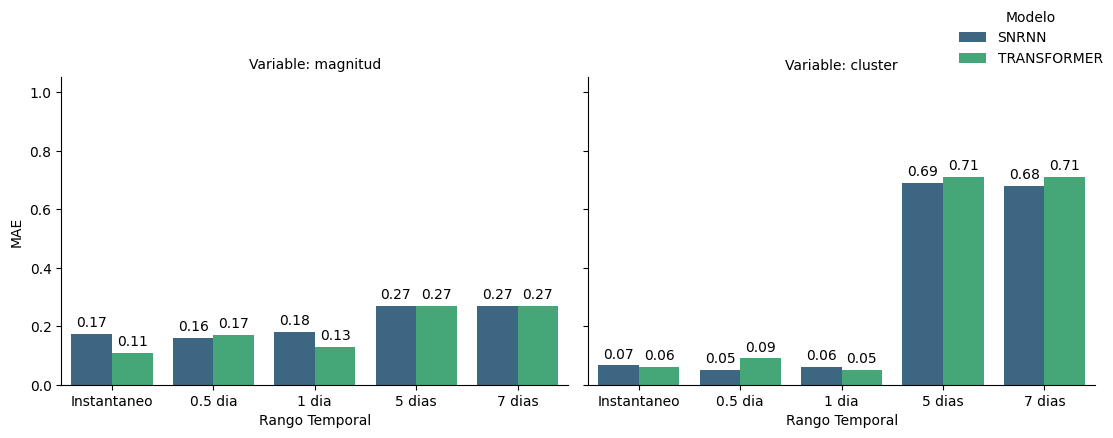

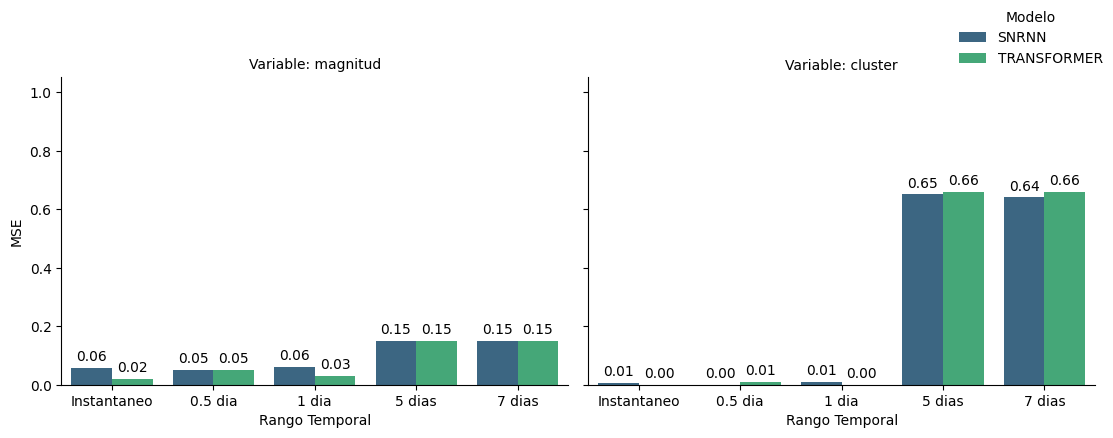

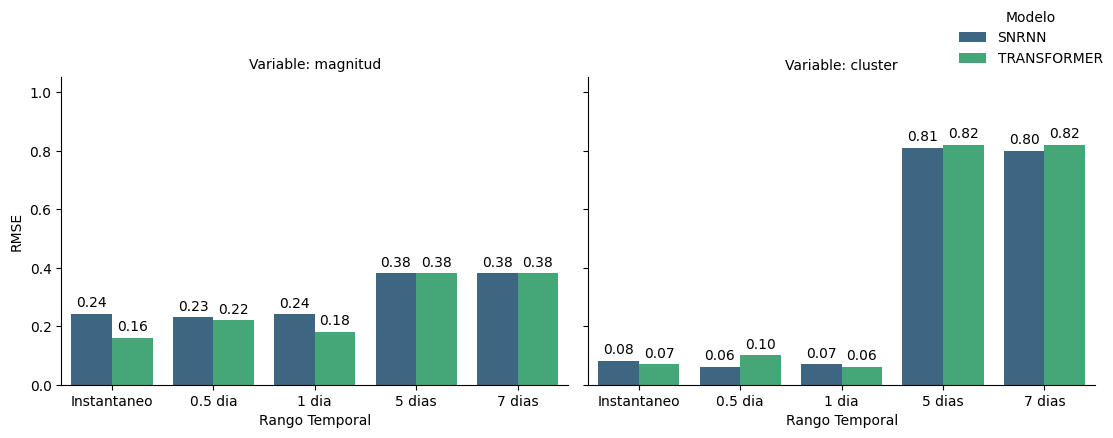

In [ ]:
# se aplico el grafico para las 3 metricas

######## Plot MAE ########
df_acc = df_new_base[df_new_base['Variable']!='timestamp']
g = sns.catplot(
    data=df_acc,
    x='Rango_Temporal',
    y='MAE',
    hue='Modelo',
    col='Variable',
    kind='bar',
    palette='viridis',
    height=4,
    aspect=1.2
)

# Títulos, ejes, límites
g.set_titles("Variable: {col_name}")
g.set_axis_labels("Rango Temporal", "MAE")
g.set(ylim=(0, 1.05))

# Agregar etiquetas sobre las barras (por cada gráfico)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

# Mover leyenda debajo del gráfico
g._legend.set_bbox_to_anchor((1, 1))  # (x, y) relativo al gráfico
g._legend.set_title("Modelo")

plt.tight_layout()
plt.show()

######## Plot MSE ########
df_acc = df_new_base[df_new_base['Variable']!='timestamp']
g = sns.catplot(
    data=df_acc,
    x='Rango_Temporal',
    y='MSE',
    hue='Modelo',
    col='Variable',
    kind='bar',
    palette='viridis',
    height=4,
    aspect=1.2
)

# Títulos, ejes, límites
g.set_titles("Variable: {col_name}")
g.set_axis_labels("Rango Temporal", "MSE")
g.set(ylim=(0, 1.05))

# Agregar etiquetas sobre las barras (por cada gráfico)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

# Mover leyenda debajo del gráfico
g._legend.set_bbox_to_anchor((1, 1))
g._legend.set_title("Modelo")

plt.tight_layout()
plt.show()

######## Plot RMSE ########
df_acc = df_new_base[df_new_base['Variable']!='timestamp']
g = sns.catplot(
    data=df_acc,
    x='Rango_Temporal',
    y='RMSE',
    hue='Modelo',
    col='Variable',
    kind='bar',
    palette='viridis',
    height=4,
    aspect=1.2
)

# Títulos, ejes, límites
g.set_titles("Variable: {col_name}")
g.set_axis_labels("Rango Temporal", "RMSE")
g.set(ylim=(0, 1.05))

# Agregar etiquetas sobre las barras (por cada gráfico)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

# Mover leyenda debajo del gráfico
g._legend.set_bbox_to_anchor((1, 1))  # (x, y) relativo al gráfico
g._legend.set_title("Modelo")

plt.tight_layout()
plt.show()

**Accuracy**

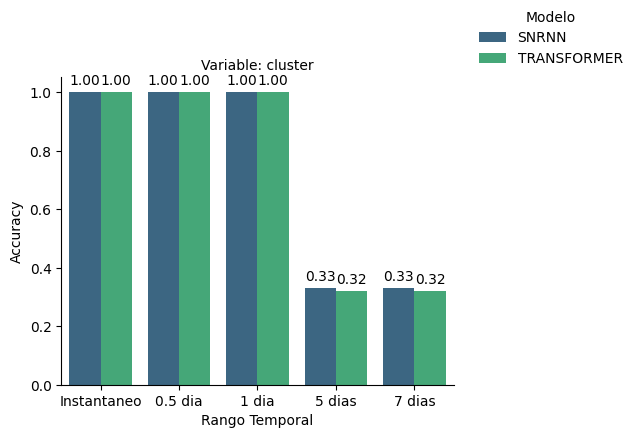

In [ ]:
df_acc = df_new_base.dropna(subset=['Accuracy'])

g = sns.catplot(
    data=df_acc,
    x='Rango_Temporal',
    y='Accuracy',
    hue='Modelo',
    col='Variable',
    kind='bar',
    palette='viridis',
    height=4,
    aspect=1.2
)

g.set_titles("Variable: {col_name}")
g.set_axis_labels("Rango Temporal", "Accuracy")
g.set(ylim=(0, 1.05))

# Agregar etiquetas sobre las barras (por cada gráfico)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

# Mover leyenda debajo del gráfico
g._legend.set_bbox_to_anchor((1, 1))  # (x, y) relativo al gráfico
g._legend.set_title("Modelo")

g.tight_layout()
plt.show()

**Grafico cruzados**

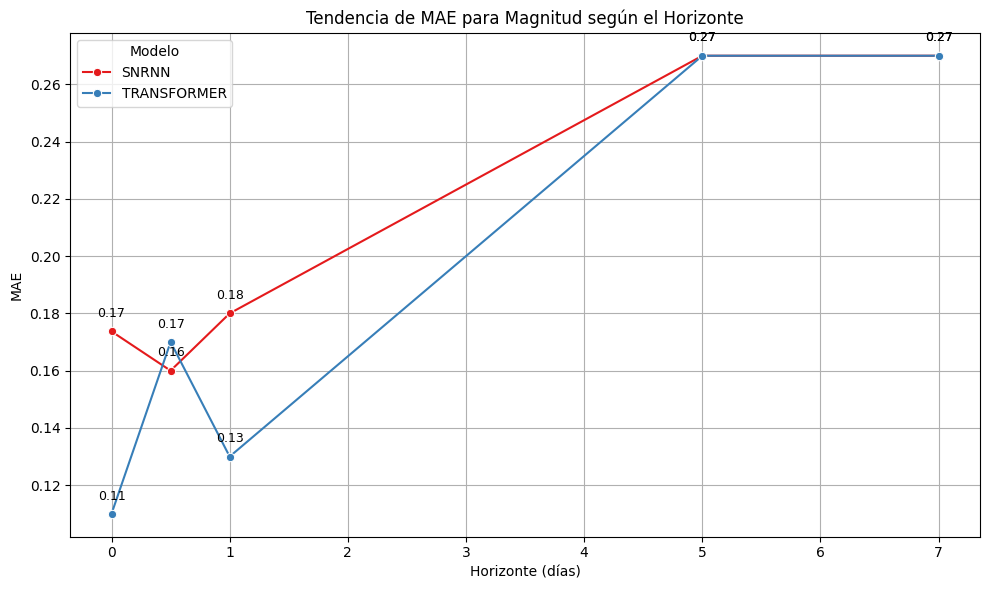

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
########## MAE ##########
# cruce de informacion entre MAE y los horizontes
# para los dos modelos
# Ordenar los horizontes en días
orden = {
    'Instantaneo': 0,
    '0.5 dia': 0.5,
    '1 dia': 1,
    '5 dias': 5,
    '7 dias': 7
}
df_line = df_new_base.copy()
df_line['H_dias'] = df_line['Rango_Temporal'].map(orden)

# Filtrar solo magnitud
df_magnitud = df_line[df_line['Variable'] == 'magnitud']

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_magnitud,
    x='H_dias',
    y='MAE',
    hue='Modelo',
    marker='o',
    palette='Set1'
)

# Agregar etiquetas numéricas encima de cada punto
for modelo in df_magnitud['Modelo'].unique():
    df_m = df_magnitud[df_magnitud['Modelo'] == modelo]
    for x, y in zip(df_m['H_dias'], df_m['MAE']):
        ax.text(x, y + 0.005, f'{y:.2f}', ha='center', fontsize=9)

plt.title('Tendencia de MAE para Magnitud según el Horizonte')
plt.xlabel('Horizonte (días)')
plt.ylabel('MAE')
plt.grid(True)
plt.tight_layout()
plt.show()

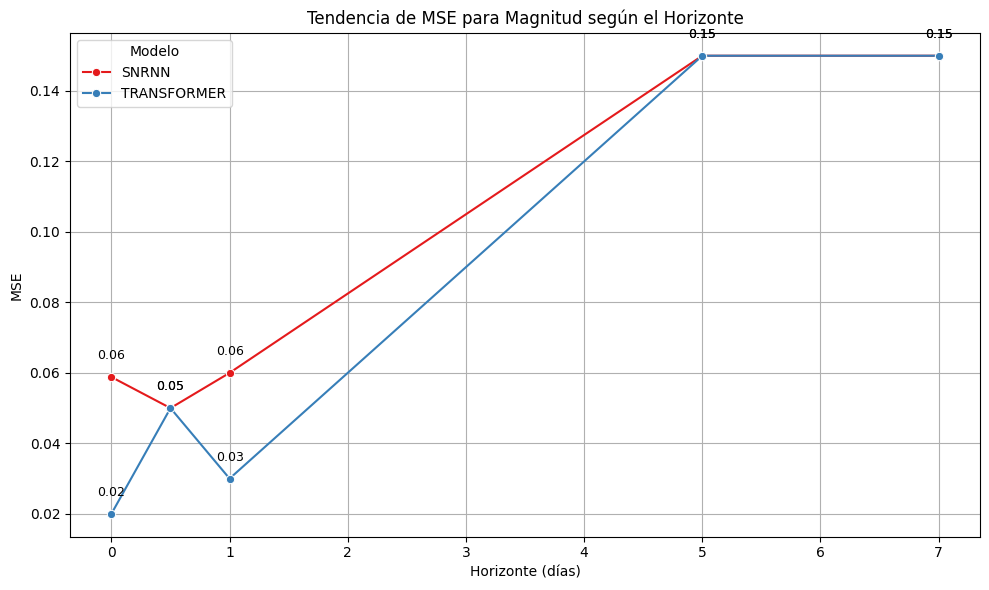

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
########## MSE ##########
# cruce de informacion entre MSE y los horizontes
# para los dos modelos
# Ordenar los horizontes en días
orden = {
    'Instantaneo': 0,
    '0.5 dia': 0.5,
    '1 dia': 1,
    '5 dias': 5,
    '7 dias': 7
}
df_line = df_new_base.copy()
df_line['H_dias'] = df_line['Rango_Temporal'].map(orden)

# Filtrar solo magnitud
df_magnitud = df_line[df_line['Variable'] == 'magnitud']

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_magnitud,
    x='H_dias',
    y='MSE',
    hue='Modelo',
    marker='o',
    palette='Set1'
)

# Agregar etiquetas numéricas encima de cada punto
for modelo in df_magnitud['Modelo'].unique():
    df_m = df_magnitud[df_magnitud['Modelo'] == modelo]
    for x, y in zip(df_m['H_dias'], df_m['MSE']):
        ax.text(x, y + 0.005, f'{y:.2f}', ha='center', fontsize=9)

plt.title('Tendencia de MSE para Magnitud según el Horizonte')
plt.xlabel('Horizonte (días)')
plt.ylabel('MSE')
plt.grid(True)
plt.tight_layout()
plt.show()

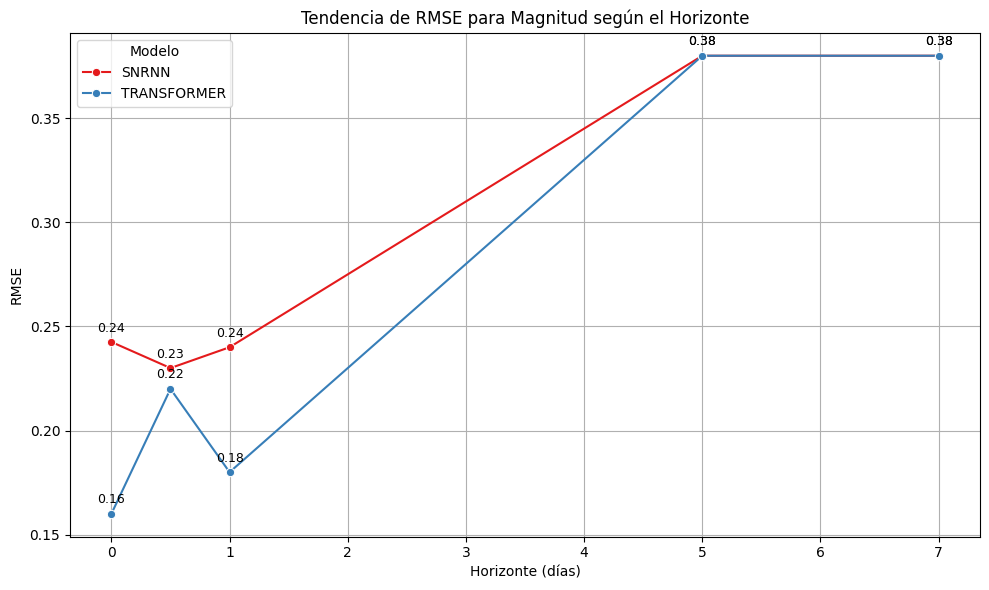

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
########## RMSE ##########
# cruce de informacion entre RMSE y los horizontes
# para los dos modelos
# Ordenar los horizontes en días
orden = {
    'Instantaneo': 0,
    '0.5 dia': 0.5,
    '1 dia': 1,
    '5 dias': 5,
    '7 dias': 7
}
df_line = df_new_base.copy()
df_line['H_dias'] = df_line['Rango_Temporal'].map(orden)

# Filtrar solo magnitud
df_magnitud = df_line[df_line['Variable'] == 'magnitud']

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_magnitud,
    x='H_dias',
    y='RMSE',
    hue='Modelo',
    marker='o',
    palette='Set1'
)

# Agregar etiquetas numéricas encima de cada punto
for modelo in df_magnitud['Modelo'].unique():
    df_m = df_magnitud[df_magnitud['Modelo'] == modelo]
    for x, y in zip(df_m['H_dias'], df_m['RMSE']):
        ax.text(x, y + 0.005, f'{y:.2f}', ha='center', fontsize=9)

plt.title('Tendencia de RMSE para Magnitud según el Horizonte')
plt.xlabel('Horizonte (días)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Timestamp**

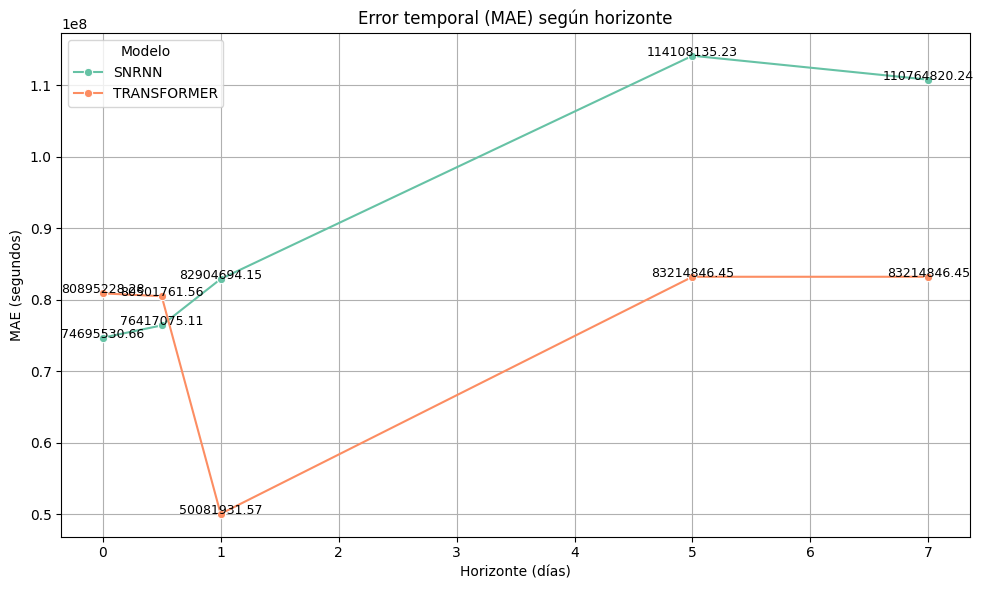

In [ ]:
# importamos las librerias
import seaborn as sns
import matplotlib.pyplot as plt
############# MAE #############
# cruce de informacion entre MAE y los horizontes
# para los dos modelos
orden = {
    'Instantaneo': 0,
    '0.5 dia': 0.5,
    '1 dia': 1,
    '5 dias': 5,
    '7 dias': 7
}
df_temp = df_new_base[df_new_base['Variable'] == 'timestamp'].copy()
df_temp['H_dias'] = df_temp['Rango_Temporal'].map(orden)

plt.figure(figsize=(10,6))
ax=sns.lineplot(data=df_temp, x='H_dias', y='MAE', hue='Modelo', marker='o', palette='Set2')

# Agregar etiquetas numéricas encima de cada punto
for modelo in df_temp['Modelo'].unique():
    df_m = df_temp[df_temp['Modelo'] == modelo]
    for x, y in zip(df_m['H_dias'], df_m['MAE']):
        ax.text(x, y + 0.005, f'{y:.2f}', ha='center', fontsize=9)

plt.title("Error temporal (MAE) según horizonte")
plt.xlabel("Horizonte (días)")
plt.ylabel("MAE (segundos)")
plt.grid(True)
plt.tight_layout()
plt.show()

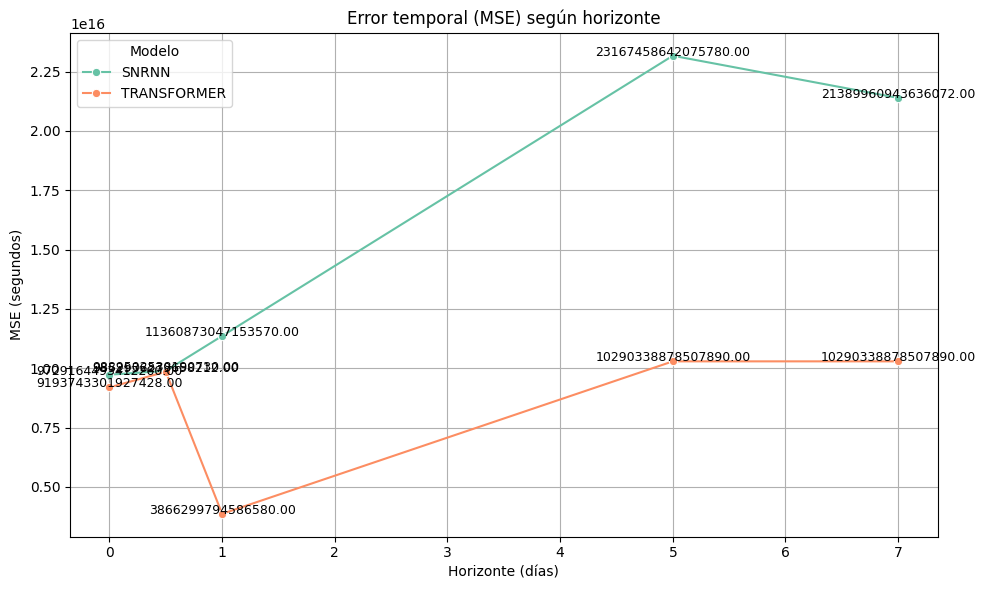

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
############# MSE #############
# cruce de informacion entre MSE y los horizontes
# para los dos modelos
orden = {
    'Instantaneo': 0,
    '0.5 dia': 0.5,
    '1 dia': 1,
    '5 dias': 5,
    '7 dias': 7
}
df_temp = df_new_base[df_new_base['Variable'] == 'timestamp'].copy()
df_temp['H_dias'] = df_temp['Rango_Temporal'].map(orden)

plt.figure(figsize=(10,6))
ax=sns.lineplot(data=df_temp, x='H_dias', y='MSE', hue='Modelo', marker='o', palette='Set2')

# Agregar etiquetas numéricas encima de cada punto
for modelo in df_temp['Modelo'].unique():
    df_m = df_temp[df_temp['Modelo'] == modelo]
    for x, y in zip(df_m['H_dias'], df_m['MSE']):
        ax.text(x, y + 0.005, f'{y:.2f}', ha='center', fontsize=9)

plt.title("Error temporal (MSE) según horizonte")
plt.xlabel("Horizonte (días)")
plt.ylabel("MSE (segundos)")
plt.grid(True)
plt.tight_layout()
plt.show()

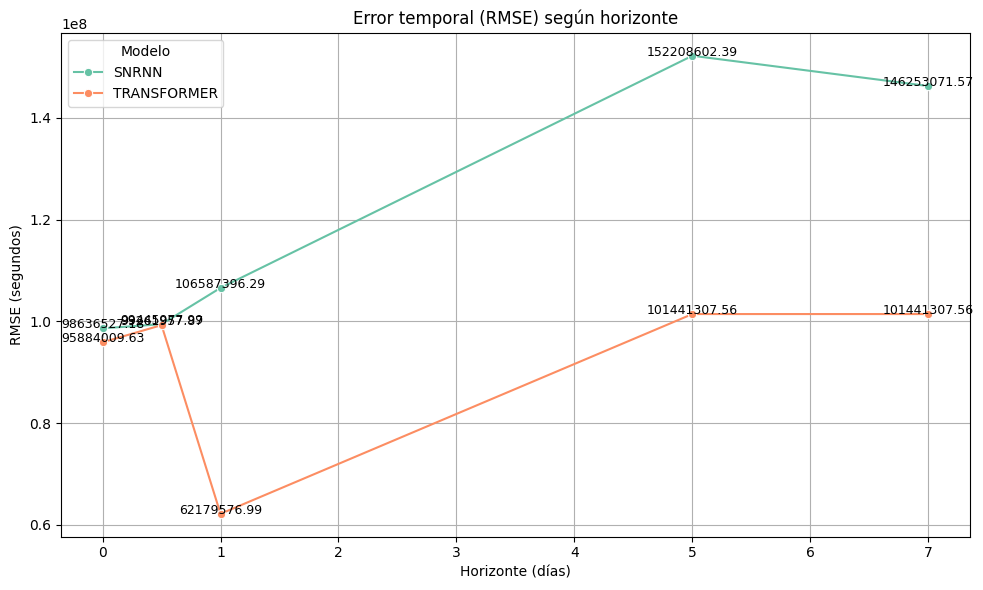

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
############# RMSE #############
# cruce de informacion entre RMSE y los horizontes
# para los dos modelos
orden = {
    'Instantaneo': 0,
    '0.5 dia': 0.5,
    '1 dia': 1,
    '5 dias': 5,
    '7 dias': 7
}
df_temp = df_new_base[df_new_base['Variable'] == 'timestamp'].copy()
df_temp['H_dias'] = df_temp['Rango_Temporal'].map(orden)

plt.figure(figsize=(10,6))
ax=sns.lineplot(data=df_temp, x='H_dias', y='RMSE', hue='Modelo', marker='o', palette='Set2')

# Agregar etiquetas numéricas encima de cada punto
for modelo in df_temp['Modelo'].unique():
    df_m = df_temp[df_temp['Modelo'] == modelo]
    for x, y in zip(df_m['H_dias'], df_m['RMSE']):
        ax.text(x, y + 0.005, f'{y:.2f}', ha='center', fontsize=9)

plt.title("Error temporal (RMSE) según horizonte")
plt.xlabel("Horizonte (días)")
plt.ylabel("RMSE (segundos)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
global_end = time.time()
print(f"Tiempo total de ejecución: {(global_end - global_start)/60:.2f} minutos")

Tiempo total de ejecución: 0.08 minutos
